# 06: Interactive IV Model IIVM

This lesson is a full tutorial on `DoubleMLIIVM`, the interactive instrumental-variable model for a binary treatment and a binary instrument.

The previous notebook handled binary treatments under observed-control adjustment. Here we add noncompliance and instrument-induced treatment changes. The treatment is binary, the instrument is binary, and the target is a local effect: the effect for units whose treatment status is shifted by the instrument.

The main point is conceptual as much as computational. Binary IV estimates are not ordinary ATE estimates. They are local effects tied to compliance behavior and instrument validity.

## Learning Goals

By the end, you should be able to:

- Explain the IIVM setup for binary treatment and binary instrument data.
- Distinguish ATE, ATT-style targets, and LATE.
- Explain compliers, always-takers, never-takers, and defiers.
- State the IV assumptions for binary instruments: relevance, exclusion, independence after controls, and monotonicity.
- Understand the `DoubleMLIIVM` nuisance roles: `ml_g`, `ml_m`, and `ml_r`.
- Manually compute the cross-fitted IIVM ratio score.
- Fit `DoubleMLIIVM` and diagnose first-stage strength, instrument overlap, nuisance losses, score contributions, and split stability.
- Explain why weak instruments, invalid instruments, or wrong subgroup assumptions change the meaning of the estimate.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use controlled semi-synthetic datasets with known nuisance functions or known treatment effects to study **Interactive IV Model IIVM**. Double machine learning is easiest to understand when the data contain realistic nuisance structure but still give us a benchmark for the target parameter. That lets the notebook separate estimation error from identification failure.

Read each row as a unit with pre-treatment covariates, a treatment or instrument, and an outcome. The learner comparisons are experiments about orthogonalization, cross-fitting, overlap, sample splitting, and decision targets. The experiment shows a setting where treatment choice is endogenous and identification must come from a source of quasi-random variation. The experiment combines binary treatment and instrument logic, so the causal target is local to compliers under the stated assumptions.

The estimators are causal only under the stated design assumptions. Flexible machine-learning nuisance models help with prediction bias, but they do not replace causal identification.


## Mathematical Foundation

<!-- math-foundation-note -->

The interactive IV model targets a local effect for compliers when an instrument $Z$ shifts treatment $D$. A simple Wald estimand is

$$
\theta_{LATE}=\frac{\mathbb{E}(Y\mid Z=1)-\mathbb{E}(Y\mid Z=0)}{\mathbb{E}(D\mid Z=1)-\mathbb{E}(D\mid Z=0)}.
$$

With controls, DoubleML replaces the numerator and denominator with orthogonalized scores involving outcome, treatment, and instrument nuisance functions. The denominator is the first-stage signal.





## Tutorial Workflow

### From ATE to LATE

For a binary treatment, the ATE is:

$$
E[Y(1)-Y(0)].
$$

That target averages treatment effects over everyone. In a binary IV design with noncompliance, the instrument does not necessarily move everyone into treatment. Some units take treatment regardless of the instrument, some never take treatment, and some take treatment only when encouraged.

The local average treatment effect is the treatment effect for the instrument-responsive units:

$$
LATE = E[Y(1)-Y(0) \mid \text{complier}].
$$

When compliance probability varies with covariates, the model target is a compliance-weighted local effect. In the synthetic data we can compute that target exactly; in real data we usually cannot observe compliance type directly.

### Compliance Types

With a binary instrument `Z` and binary treatment `D`, define two potential treatment states:

$$
D(1) \quad \text{and} \quad D(0).
$$

`D(1)` is whether the unit would take treatment if instrumented. `D(0)` is whether the unit would take treatment if not instrumented.

The common compliance types are:

- Complier: `D(1)=1`, `D(0)=0`.
- Always-taker: `D(1)=1`, `D(0)=1`.
- Never-taker: `D(1)=0`, `D(0)=0`.
- Defier: `D(1)=0`, `D(0)=1`.

The usual monotonicity assumption rules out defiers: the instrument should not make anyone less likely to take treatment.

### IIVM Assumptions

A binary IV design needs several assumptions:

- Relevance: the instrument changes treatment probability after adjusting for controls.
- Exclusion: the instrument affects the outcome only through treatment.
- Conditional independence: after adjusting for controls, the instrument is independent of potential outcomes and potential treatment states.
- Monotonicity: the instrument does not push some units in the opposite direction.
- Overlap for the instrument: every relevant covariate profile has a nonzero chance of both instrument states.

The data can help screen relevance and overlap. Exclusion, independence, and monotonicity require design evidence.

### IIVM Nuisance Functions

`DoubleMLIIVM` estimates these nuisance components:

$$
g_0(0, X) = E[Y \mid Z=0, X]
$$

$$
g_0(1, X) = E[Y \mid Z=1, X]
$$

$$
m_0(X) = P(Z=1 \mid X)
$$

and

$$
r_0(0, X) = P(D=1 \mid Z=0, X), \quad r_0(1, X) = P(D=1 \mid Z=1, X).
$$

In the API:

- `ml_g` predicts the outcome as a function of instrument status and controls.
- `ml_m` predicts the instrument propensity.
- `ml_r` predicts treatment take-up as a function of instrument status and controls.

The target is the ratio:

$$
\theta_0 = \frac{E[g_0(1,X)-g_0(0,X)]}{E[r_0(1,X)-r_0(0,X)]}.
$$

#### Runtime Note

This lesson fits several cross-fitted binary IV models, a manual IIVM estimator, subgroup comparisons, and a repeated-splitting check. On a typical laptop, the full run should take roughly two to five minutes.

The stress tests use synthetic oracle calculations where possible so that the conceptual lessons stay fast.

#### Setup

The code below prepares the notebook environment. It creates output folders, keeps matplotlib cache files inside the tutorial output folder, imports scientific Python libraries, and records package versions.

The path logic supports running from the repository root or directly from the tutorial folder.

In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import warnings

NOTEBOOK_PREFIX = "06"
RANDOM_STATE = 2026

CURRENT_DIR = Path.cwd().resolve()
if CURRENT_DIR.name == "doubleml":
    REPO_ROOT = CURRENT_DIR.parents[2]
elif (CURRENT_DIR / "notebooks" / "tutorials" / "doubleml").exists():
    REPO_ROOT = CURRENT_DIR
else:
    REPO_ROOT = CURRENT_DIR

OUTPUT_DIR = REPO_ROOT / "notebooks" / "tutorials" / "doubleml" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"

for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LassoCV, LinearRegression, LogisticRegressionCV
from sklearn.metrics import log_loss, mean_absolute_error, mean_squared_error, roc_auc_score, r2_score
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm

import doubleml as dml
from doubleml import DoubleMLData, DoubleMLIIVM, DoubleMLIRM

warnings.filterwarnings("ignore", category=ConvergenceWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

package_versions = pd.DataFrame(
    [
        {"package": "doubleml", "version": dml.__version__},
        {"package": "numpy", "version": np.__version__},
        {"package": "pandas", "version": pd.__version__},
        {"package": "seaborn", "version": sns.__version__},
        {"package": "statsmodels", "version": sm.__version__},
    ]
)
package_versions.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(package_versions)


,package,version
0,doubleml,0.11.2
1,numpy,2.4.4
2,pandas,3.0.2
3,seaborn,0.13.2
4,statsmodels,0.14.6


The package table is saved as part of the reproducibility record. Binary IV workflows depend on classifier behavior, cross-fitting splits, and package defaults.

This is a reproducibility check rather than causal evidence. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


#### Helper Functions

The next cell defines utilities for saving tables, computing simple baselines, computing manual ratio scores, cross-fitting IIVM nuisance functions, and extracting DoubleML diagnostics.

The manual IIVM formula is the most important helper. It estimates a numerator effect of the instrument on the outcome and a denominator effect of the instrument on treatment, then takes their ratio.

In [2]:
# Define reusable helpers for the Helper Functions section.
def save_table(df, name):
    """
    Idea: Save a result table to the notebook table directory and return the same DataFrame for display.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    name : str
        Short name used for the saved artifact or scenario label.
    
    Returns
    -------
    pd.DataFrame
        Same table after writing it to the tutorial table directory.
    """
    path = TABLE_DIR / f"{NOTEBOOK_PREFIX}_{name}.csv"
    df.to_csv(path, index=False)
    return df


def sigmoid(x):
    """
    Idea: Map a linear score to a probability on the 0 to 1 scale for treatment assignment or simulation logic.
    
    Parameters
    ----------
    x : str or array-like
        First variable, column name, or numeric input in the comparison.
    
    Returns
    -------
    np.ndarray
        Probability-scale values obtained by applying the logistic transform elementwise.
    """
    return 1.0 / (1.0 + np.exp(-x))


def rmse(y_true, y_pred):
    """
    Idea: Compute root mean squared error between an oracle target and an estimated or predicted value.
    
    Parameters
    ----------
    y_true : array-like
        Reference outcome, oracle value, or known target used for evaluation.
    y_pred : array-like
        Predicted outcome or estimated value being evaluated.
    
    Returns
    -------
    float
        Root mean squared error between the reference values and predictions.
    """
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mean_difference_summary(y, group, label, target="difference"):
    """
    Idea: Assemble a summary of the mean difference summary with the quantities needed for interpretation.
    
    Parameters
    ----------
    y : str or array-like
        Outcome, second variable, or numeric input in the comparison.
    group : object
        Group or segment label being summarized.
    label : str
        Short label attached to a scenario, method, or plotted result.
    target : str or array-like
        Outcome, metric, or variable whose transformed value is needed.
    
    Returns
    -------
    dict[str, float]
        Treated-control mean-difference summary with estimate, standard error, interval, and target label.
    """
    group = np.asarray(group)
    y = np.asarray(y)
    high = y[group == 1]
    low = y[group == 0]
    theta_hat = float(high.mean() - low.mean())
    std_error = float(np.sqrt(high.var(ddof=1) / len(high) + low.var(ddof=1) / len(low)))
    return {
        "estimator": label,
        "target": target,
        "theta_hat": theta_hat,
        "std_error": std_error,
        "ci_95_lower": theta_hat - 1.96 * std_error,
        "ci_95_upper": theta_hat + 1.96 * std_error,
        "p_value": np.nan,
    }


def treatment_ols_summary(y, X, treatment_col, label):
    """
    Idea: Assemble a summary of the treatment OLS summary with the quantities needed for interpretation.
    
    Parameters
    ----------
    y : str or array-like
        Outcome, second variable, or numeric input in the comparison.
    X : pd.DataFrame or np.ndarray
        Feature matrix containing pre-treatment covariates or effect modifiers.
    treatment_col : str
        Name of the treatment or intervention column.
    label : str
        Short label attached to a scenario, method, or plotted result.
    
    Returns
    -------
    dict[str, float]
        Treatment-slope summary row from the fitted OLS model.
    """
    X_design = sm.add_constant(X, has_constant="add")
    fit = sm.OLS(y, X_design).fit(cov_type="HC1")
    row = fit.summary2().tables[1].loc[treatment_col]
    return {
        "estimator": label,
        "target": "observed-control treatment slope",
        "theta_hat": float(row["Coef."]),
        "std_error": float(row["Std.Err."]),
        "ci_95_lower": float(row["[0.025"]),
        "ci_95_upper": float(row["0.975]"]),
        "p_value": float(row["P>|z|"]),
    }


def wald_summary(y, d, z, label):
    """
    Idea: Assemble the Wald ratio estimate, first-stage strength, and reduced-form evidence for an IV design.
    
    Parameters
    ----------
    y : str or array-like
        Outcome, second variable, or numeric input in the comparison.
    d : object
        Treatment or decision indicator used by the causal score.
    z : str or array-like
        Instrument, conditioning variable, or third input used by the model.
    label : str
        Short label attached to a scenario, method, or plotted result.
    
    Returns
    -------
    dict[str, float]
        Wald-style IV summary row with numerator, denominator, estimate, and uncertainty fields.
    """
    y = np.asarray(y)
    d = np.asarray(d)
    z = np.asarray(z)
    numerator = y[z == 1].mean() - y[z == 0].mean()
    denominator = d[z == 1].mean() - d[z == 0].mean()
    theta_hat = float(numerator / denominator)
    influence = (z / z.mean()) * (y - theta_hat * d) - ((1 - z) / (1 - z).mean()) * (y - theta_hat * d)
    std_error = float(np.std(influence, ddof=1) / (abs(denominator) * np.sqrt(len(y))))
    return {
        "estimator": label,
        "target": "raw Wald LATE-style ratio",
        "theta_hat": theta_hat,
        "std_error": std_error,
        "ci_95_lower": theta_hat - 1.96 * std_error,
        "ci_95_upper": theta_hat + 1.96 * std_error,
        "p_value": np.nan,
        "wald_numerator": float(numerator),
        "wald_denominator": float(denominator),
    }


def residualized_wald_summary(y, d, z, X, label):
    """
    Idea: Compute a Wald-style IV summary after residualizing treatment, outcome, and instrument on controls.
    
    Parameters
    ----------
    y : str or array-like
        Outcome, second variable, or numeric input in the comparison.
    d : object
        Treatment or decision indicator used by the causal score.
    z : str or array-like
        Instrument, conditioning variable, or third input used by the model.
    X : pd.DataFrame or np.ndarray
        Feature matrix containing pre-treatment covariates or effect modifiers.
    label : str
        Short label attached to a scenario, method, or plotted result.
    
    Returns
    -------
    dict[str, float]
        Residualized IV summary row after adjusting outcome, treatment, and instrument for controls.
    """
    y_resid = y - LinearRegression().fit(X, y).predict(X)
    d_resid = d - LinearRegression().fit(X, d).predict(X)
    z_resid = z - LinearRegression().fit(X, z).predict(X)
    numerator = float(np.mean(z_resid * y_resid))
    denominator = float(np.mean(z_resid * d_resid))
    theta_hat = numerator / denominator
    psi = z_resid * (y_resid - theta_hat * d_resid)
    std_error = float(np.sqrt(np.mean(psi ** 2) / (denominator ** 2 * len(y))))
    return {
        "estimator": label,
        "target": "linear residualized Wald ratio",
        "theta_hat": float(theta_hat),
        "std_error": std_error,
        "ci_95_lower": theta_hat - 1.96 * std_error,
        "ci_95_upper": theta_hat + 1.96 * std_error,
        "p_value": np.nan,
        "wald_numerator": numerator,
        "wald_denominator": denominator,
    }


def iivm_ratio_summary(y, d, z, g0_hat, g1_hat, m_hat, r0_hat, r1_hat, label):
    """
    Idea: Assemble a summary of the interactive IV model ratio summary with the quantities needed for interpretation.
    
    Parameters
    ----------
    y : str or array-like
        Outcome, second variable, or numeric input in the comparison.
    d : object
        Treatment or decision indicator used by the causal score.
    z : str or array-like
        Instrument, conditioning variable, or third input used by the model.
    g0_hat : object
        Estimated control-outcome regression prediction.
    g1_hat : object
        Estimated treated-outcome regression prediction.
    m_hat : object
        Estimated treatment or propensity nuisance prediction used by the orthogonal score.
    r0_hat : object
        Estimated nuisance prediction for the control or untreated state.
    r1_hat : object
        Estimated nuisance prediction for the treated state.
    label : str
        Short label attached to a scenario, method, or plotted result.
    
    Returns
    -------
    dict[str, float]
        IIVM Wald-ratio summary with numerator, denominator, estimate, and interval.
    """
    y = np.asarray(y)
    d = np.asarray(d)
    z = np.asarray(z)
    m_hat = np.clip(np.asarray(m_hat), 0.02, 0.98)
    g0_hat = np.asarray(g0_hat)
    g1_hat = np.asarray(g1_hat)
    r0_hat = np.clip(np.asarray(r0_hat), 0.01, 0.99)
    r1_hat = np.clip(np.asarray(r1_hat), 0.01, 0.99)

    numerator_score = g1_hat - g0_hat + z * (y - g1_hat) / m_hat - (1 - z) * (y - g0_hat) / (1 - m_hat)
    denominator_score = r1_hat - r0_hat + z * (d - r1_hat) / m_hat - (1 - z) * (d - r0_hat) / (1 - m_hat)
    numerator = float(np.mean(numerator_score))
    denominator = float(np.mean(denominator_score))
    theta_hat = numerator / denominator
    ratio_score = numerator_score - theta_hat * denominator_score
    std_error = float(np.std(ratio_score, ddof=1) / (abs(denominator) * np.sqrt(len(y))))
    return {
        "estimator": label,
        "target": "LATE",
        "theta_hat": float(theta_hat),
        "std_error": std_error,
        "ci_95_lower": theta_hat - 1.96 * std_error,
        "ci_95_upper": theta_hat + 1.96 * std_error,
        "p_value": np.nan,
        "iivm_numerator": numerator,
        "iivm_denominator": denominator,
    }


def crossfit_iivm_nuisances(X, y, d, z, outcome_learner, instrument_learner, treatment_learner, n_splits=5, random_state=RANDOM_STATE):
    """
    Idea: Cross-fit the nuisance models for the crossfit interactive IV model nuisances design so evaluation uses out-of-fold predictions.
    
    Parameters
    ----------
    X : pd.DataFrame or np.ndarray
        Feature matrix containing pre-treatment covariates or effect modifiers.
    y : str or array-like
        Outcome, second variable, or numeric input in the comparison.
    d : object
        Treatment or decision indicator used by the causal score.
    z : str or array-like
        Instrument, conditioning variable, or third input used by the model.
    outcome_learner : object
        Model used to learn the outcome regression nuisance function.
    instrument_learner : object
        Model used to learn the instrument-related nuisance function.
    treatment_learner : object
        Model used to learn the treatment or propensity nuisance function.
    n_splits : object
        Number of folds or sample splits used for cross-fitting.
    random_state : int
        Random-state value used to make sampling or model fitting reproducible.
    
    Returns
    -------
    tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]
        Out-of-fold IIVM nuisance predictions for outcome, treatment, and instrument components.
    """
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    g0_hat = np.zeros(len(y))
    g1_hat = np.zeros(len(y))
    m_hat = np.zeros(len(y))
    r0_hat = np.zeros(len(y))
    r1_hat = np.zeros(len(y))

    for train_idx, test_idx in cv.split(X):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y[train_idx]
        d_train = d[train_idx]
        z_train = z[train_idx]

        g0_model = clone(outcome_learner).fit(X_train[z_train == 0], y_train[z_train == 0])
        g1_model = clone(outcome_learner).fit(X_train[z_train == 1], y_train[z_train == 1])
        m_model = clone(instrument_learner).fit(X_train, z_train)
        r0_model = clone(treatment_learner).fit(X_train[z_train == 0], d_train[z_train == 0])
        r1_model = clone(treatment_learner).fit(X_train[z_train == 1], d_train[z_train == 1])

        g0_hat[test_idx] = g0_model.predict(X_test)
        g1_hat[test_idx] = g1_model.predict(X_test)
        m_hat[test_idx] = m_model.predict_proba(X_test)[:, 1]
        r0_hat[test_idx] = r0_model.predict_proba(X_test)[:, 1]
        r1_hat[test_idx] = r1_model.predict_proba(X_test)[:, 1]

    return g0_hat, g1_hat, np.clip(m_hat, 0.02, 0.98), np.clip(r0_hat, 0.01, 0.99), np.clip(r1_hat, 0.01, 0.99)


def prediction_vector(doubleml_model, learner_key):
    """
    Idea: Return predictions from a learner as a flat numeric vector with shape compatible with later diagnostics.
    
    Parameters
    ----------
    doubleml_model : object
        Model object used for `doubleml` fitting, prediction, or comparison.
    learner_key : object
        Dictionary key identifying which learner configuration is being evaluated.
    
    Returns
    -------
    np.ndarray
        One-dimensional prediction array aligned with the evaluation rows.
    """
    arr = np.asarray(doubleml_model.predictions[learner_key])
    if arr.ndim != 3:
        raise ValueError(f"Expected a 3D prediction array, got shape {arr.shape}")
    return arr[:, 0, 0]


def learner_loss_table(doubleml_model, model_label):
    """
    Idea: Assemble a DataFrame for the learner loss table so the result can be displayed and saved consistently.
    
    Parameters
    ----------
    doubleml_model : object
        Model object used for `doubleml` fitting, prediction, or comparison.
    model_label : str
        Display label for `model`.
    
    Returns
    -------
    pd.DataFrame
        Out-of-fold nuisance prediction loss table by learner and nuisance role.
    """
    losses = doubleml_model.evaluate_learners()
    rows = []
    for learner_name, values in losses.items():
        arr = np.asarray(values)
        rows.append(
            {
                "model": model_label,
                "learner": learner_name,
                "mean_loss": float(np.mean(arr)),
                "min_loss": float(np.min(arr)),
                "max_loss": float(np.max(arr)),
            }
        )
    return pd.DataFrame(rows)


The manual ratio helper mirrors the IIVM target: an instrument-outcome effect divided by an instrument-treatment effect. The denominator is the first stage. If that denominator is small, the estimate becomes unstable.

#### Draw the Binary IV Design

The diagram below shows the core binary IV story.

The instrument `Z` shifts treatment `D`. Treatment affects outcome `Y`. Observed controls `X` may affect all three. Hidden factors can affect treatment and outcome, which is why observed-control IRM may fail. The IV design requires that the hidden factors do not also drive the instrument after conditioning on `X`, and that the instrument has no direct outcome path.

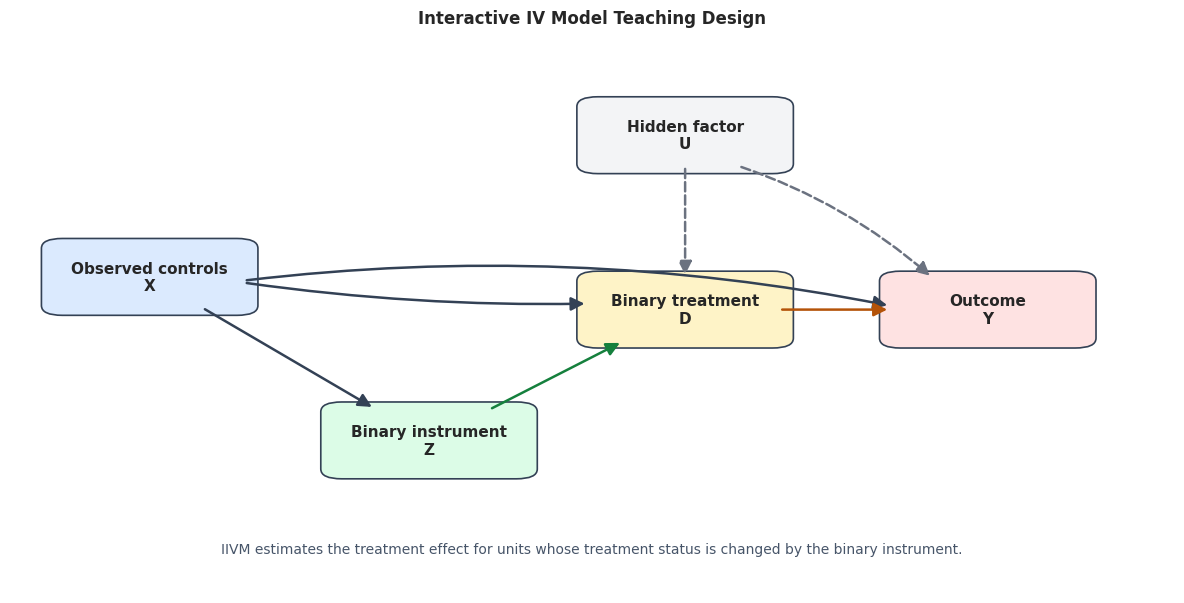

In [3]:
# Define reusable helpers for the Draw The Binary IV Design section.
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

nodes = {
    "X": {"xy": (0.12, 0.58), "label": "Observed controls\nX", "color": "#dbeafe"},
    "Z": {"xy": (0.36, 0.28), "label": "Binary instrument\nZ", "color": "#dcfce7"},
    "D": {"xy": (0.58, 0.52), "label": "Binary treatment\nD", "color": "#fef3c7"},
    "Y": {"xy": (0.84, 0.52), "label": "Outcome\nY", "color": "#fee2e2"},
    "U": {"xy": (0.58, 0.84), "label": "Hidden factor\nU", "color": "#f3f4f6"},
}

edge_specs = [
    ("X", "Z", "#334155", "solid", 0.00),
    ("X", "D", "#334155", "solid", 0.04),
    ("X", "Y", "#334155", "solid", -0.08),
    ("Z", "D", "#15803d", "solid", 0.00),
    ("D", "Y", "#b45309", "solid", 0.00),
    ("U", "D", "#6b7280", "dashed", 0.00),
    ("U", "Y", "#6b7280", "dashed", -0.10),
]

fig, ax = plt.subplots(figsize=(12, 6.2))
ax.set_axis_off()
box_w, box_h = 0.15, 0.105

def edge_endpoint(source_xy, target_xy, from_source=True):
    """
    Idea: Choose the correct endpoint marker for a directed, undirected, or partially directed causal edge.
    
    Parameters
    ----------
    source_xy : object
        Starting coordinate of a plotted arrow or graph edge.
    target_xy : object
        Ending coordinate of a plotted arrow or graph edge.
    from_source : object
        Whether the endpoint should be calculated from the source side of the edge.
    
    Returns
    -------
    tuple[float, float]
        Adjusted endpoint coordinate for a directed or partially directed graph edge.
    """
    x0, y0 = source_xy
    x1, y1 = target_xy
    dx, dy = x1 - x0, y1 - y0
    scale = 1.0 / max(abs(dx) / (box_w / 2), abs(dy) / (box_h / 2))
    if from_source:
        return (x0 + dx * scale * 1.08, y0 + dy * scale * 1.08)
    return (x1 - dx * scale * 1.12, y1 - dy * scale * 1.12)

for spec in nodes.values():
    x, y_pos = spec["xy"]
    rect = FancyBboxPatch(
        (x - box_w / 2, y_pos - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.018",
        facecolor=spec["color"],
        edgecolor="#334155",
        linewidth=1.2,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.text(x, y_pos, spec["label"], ha="center", va="center", fontsize=11, fontweight="bold", zorder=4)

for start, end, color, style, rad in edge_specs:
    start_xy = edge_endpoint(nodes[start]["xy"], nodes[end]["xy"], from_source=True)
    end_xy = edge_endpoint(nodes[start]["xy"], nodes[end]["xy"], from_source=False)
    arrow = FancyArrowPatch(
        start_xy,
        end_xy,
        arrowstyle="-|>",
        mutation_scale=20,
        linewidth=1.8,
        color=color,
        linestyle=style,
        connectionstyle=f"arc3,rad={rad}",
        zorder=5,
    )
    ax.add_patch(arrow)

ax.text(
    0.50,
    0.08,
    "IIVM estimates the treatment effect for units whose treatment status is changed by the binary instrument.",
    ha="center",
    va="center",
    fontsize=10,
    color="#475569",
)
ax.set_title("Interactive IV Model Teaching Design", pad=18)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_iivm_design_dag.png", dpi=160, bbox_inches="tight")
plt.show()


The diagram makes clear why this is not the same as the IRM notebook. The instrument creates a local source of treatment variation, and the estimate is tied to that variation.

#### Create an Example Dataset with Noncompliance

We now simulate a binary instrument and a binary treatment.

The instrument is an encouragement. Some units always take treatment, some never take treatment, and some comply with the encouragement. There are no defiers, so monotonicity holds by construction.

The outcome depends on the actual treatment, observed controls, and a latent factor related to compliance type. This makes direct treatment comparisons biased, but the instrument remains valid after conditioning on observed controls.

In [4]:
rng = np.random.default_rng(RANDOM_STATE)
N_OBS = 5_000

feature_cols = [
    "engagement_score",
    "need_intensity",
    "content_fit",
    "recent_activity",
    "price_sensitivity",
    "tenure_signal",
    "novelty_appetite",
    "seasonality_signal",
]

X_raw = pd.DataFrame(rng.normal(size=(N_OBS, len(feature_cols))), columns=feature_cols)

true_instrument_logit = (
    -0.10
    + 0.55 * X_raw["engagement_score"]
    - 0.35 * X_raw["price_sensitivity"]
    + 0.25 * np.sin(X_raw["content_fit"])
    + 0.20 * X_raw["seasonality_signal"]
)
true_instrument_propensity = np.clip(sigmoid(true_instrument_logit), 0.08, 0.92)
encouragement = rng.binomial(1, true_instrument_propensity, size=N_OBS)

p_complier = (
    0.45
    + 0.15 * np.tanh(X_raw["need_intensity"])
    + 0.10 * np.tanh(X_raw["novelty_appetite"])
    - 0.08 * np.tanh(X_raw["price_sensitivity"])
)
p_always = 0.18 + 0.07 * np.tanh(X_raw["engagement_score"])
p_complier = np.clip(p_complier, 0.15, 0.70)
p_always = np.clip(p_always, 0.05, 0.35)
p_never = np.clip(1 - p_complier - p_always, 0.05, 0.80)
prob_sum = p_complier + p_always + p_never
p_complier = p_complier / prob_sum
p_always = p_always / prob_sum
p_never = p_never / prob_sum

compliance_draw = rng.uniform(size=N_OBS)
compliance_type = np.where(
    compliance_draw < p_always,
    "always_taker",
    np.where(compliance_draw < p_always + p_complier, "complier", "never_taker"),
)

feature_exposure = np.where(
    compliance_type == "always_taker",
    1,
    np.where(compliance_type == "never_taker", 0, encouragement),
)

latent_compliance_factor = (
    np.where(compliance_type == "always_taker", 0.50, np.where(compliance_type == "never_taker", -0.20, 0.00))
    + rng.normal(loc=0.0, scale=0.40, size=N_OBS)
)

true_mu0 = (
    0.70 * np.sin(X_raw["engagement_score"])
    + 0.45 * X_raw["need_intensity"] ** 2
    - 0.35 * X_raw["price_sensitivity"]
    + 0.25 * X_raw["content_fit"] * X_raw["recent_activity"]
    + 0.35 * latent_compliance_factor
)
true_tau = (
    0.80
    + 0.25 * sigmoid(X_raw["engagement_score"])
    + 0.25 * X_raw["need_intensity"]
    - 0.15 * X_raw["price_sensitivity"]
    + 0.20 * (X_raw["novelty_appetite"] > 0).astype(float)
)
true_mu1 = true_mu0 + true_tau
outcome_noise = rng.normal(loc=0.0, scale=1.0, size=N_OBS)
weekly_value = true_mu0 + true_tau * feature_exposure + outcome_noise

# Population-level IIVM targets under the synthetic design.
TRUE_ATE = float(np.mean(true_tau))
TRUE_REALIZED_COMPLIER_EFFECT = float(np.mean(true_tau[compliance_type == "complier"]))
TRUE_LATE = float(np.mean(p_complier * true_tau) / np.mean(p_complier))
TRUE_FIRST_STAGE = float(np.mean(p_complier))

# Oracle conditional mean functions for the IIVM ratio.
true_r0 = p_always
true_r1 = p_always + p_complier
true_g0 = true_mu0 + true_tau * true_r0
true_g1 = true_mu0 + true_tau * true_r1

# Potential treatment states are useful for learning compliance types.
potential_d0 = np.where(compliance_type == "always_taker", 1, 0)
potential_d1 = np.where(compliance_type == "never_taker", 0, 1)

iivm_df = X_raw.assign(
    encouragement=encouragement,
    feature_exposure=feature_exposure,
    weekly_value=weekly_value,
    compliance_type=compliance_type,
    true_instrument_propensity=true_instrument_propensity,
    true_p_complier=p_complier,
    true_p_always=p_always,
    true_p_never=p_never,
    true_r0=true_r0,
    true_r1=true_r1,
    true_g0=true_g0,
    true_g1=true_g1,
    true_mu0=true_mu0,
    true_mu1=true_mu1,
    true_tau=true_tau,
    latent_compliance_factor=latent_compliance_factor,
    potential_d0=potential_d0,
    potential_d1=potential_d1,
)

iivm_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_synthetic_iivm_data.csv", index=False)
print(f"Saved synthetic IIVM data with shape {iivm_df.shape}")
print(f"Instrument rate: {iivm_df['encouragement'].mean():.3f}")
print(f"Treatment rate: {iivm_df['feature_exposure'].mean():.3f}")
print(f"True ATE: {TRUE_ATE:.3f}")
print(f"True compliance-weighted LATE: {TRUE_LATE:.3f}")
print(f"True realized complier effect: {TRUE_REALIZED_COMPLIER_EFFECT:.3f}")
print(f"True first stage: {TRUE_FIRST_STAGE:.3f}")
display(iivm_df.head())


Saved synthetic IIVM data with shape (5000, 26)
Instrument rate: 0.463
Treatment rate: 0.392
True ATE: 1.021
True compliance-weighted LATE: 1.102
True realized complier effect: 1.098
True first stage: 0.448


,engagement_score,need_intensity,content_fit,recent_activity,price_sensitivity,tenure_signal,novelty_appetite,seasonality_signal,encouragement,feature_exposure,weekly_value,compliance_type,true_instrument_propensity,true_p_complier,true_p_always,true_p_never,true_r0,true_r1,true_g0,true_g1,true_mu0,true_mu1,true_tau,latent_compliance_factor,potential_d0,potential_d1
0,-0.793122,0.240571,-1.896326,1.395772,0.638295,-0.292047,-0.311949,0.303835,0,0,-1.767914,complier,0.281765,0.410085,0.133788,0.456127,0.133788,0.543873,-1.272362,-0.926958,-1.385047,-0.542774,0.842273,-0.077700,0,1
1,-0.267660,-0.225909,0.720068,0.514705,-0.064128,-0.085477,0.160916,-0.614018,0,0,-1.428055,never_taker,0.454448,0.437756,0.161699,0.400545,0.161699,0.599455,0.076353,0.541036,-0.095292,0.966220,1.061512,-0.137787,0,0
2,-0.403750,0.548260,-0.130483,-1.374426,-0.477279,0.656622,-0.232283,-0.148733,0,0,-0.468107,never_taker,0.445890,0.537588,0.153179,0.309233,0.153179,0.690767,0.238566,0.834622,0.068727,1.177487,1.108760,-0.009748,0,0
3,0.641837,1.824610,-0.713189,1.348207,-1.230013,0.174978,-1.169530,1.351458,0,0,3.932345,complier,0.687884,0.577389,0.219630,0.202981,0.219630,0.797019,2.368826,3.295216,2.016441,3.620887,1.604447,-0.259689,0,1
4,0.833923,1.137717,-0.885533,0.684555,-0.519013,-0.457385,0.506537,0.876718,1,1,2.100733,complier,0.627637,0.656926,0.227780,0.115294,0.227780,0.884706,1.558963,2.568380,1.208961,2.745538,1.536577,0.222783,0,1


The true ATE and true local effect differ because the instrument-responsive units have a different treatment-effect mix than the full population. That is the key conceptual difference between IRM and IIVM.

#### Field Dictionary

This table documents the roles of the important columns. The hidden teaching columns are not available in real applications; they are present only so the tutorial can compare estimates with known synthetic truth.

In [5]:
field_dictionary = pd.DataFrame(
    [
        {"column": "weekly_value", "role": "outcome", "description": "Observed outcome Y."},
        {"column": "feature_exposure", "role": "binary treatment", "description": "Observed binary treatment D."},
        {"column": "encouragement", "role": "binary instrument", "description": "Observed binary instrument Z."},
        *[
            {"column": col, "role": "control", "description": "Observed pre-treatment control X."}
            for col in feature_cols
        ],
        {"column": "compliance_type", "role": "hidden teaching column", "description": "Realized synthetic compliance type; not observed in ordinary IV data."},
        {"column": "true_instrument_propensity", "role": "hidden teaching column", "description": "True P(Z=1 | X)."},
        {"column": "true_p_complier", "role": "hidden teaching column", "description": "True conditional probability of complier type."},
        {"column": "true_p_always", "role": "hidden teaching column", "description": "True conditional probability of always-taker type."},
        {"column": "true_p_never", "role": "hidden teaching column", "description": "True conditional probability of never-taker type."},
        {"column": "true_r0", "role": "hidden teaching column", "description": "True P(D=1 | Z=0, X)."},
        {"column": "true_r1", "role": "hidden teaching column", "description": "True P(D=1 | Z=1, X)."},
        {"column": "true_g0", "role": "hidden teaching column", "description": "True E[Y | Z=0, X]."},
        {"column": "true_g1", "role": "hidden teaching column", "description": "True E[Y | Z=1, X]."},
        {"column": "true_tau", "role": "hidden teaching column", "description": "True individual treatment effect."},
        {"column": "latent_compliance_factor", "role": "hidden confounding risk", "description": "Latent factor related to treatment and outcome; handled by IV design in the simulation."},
    ]
)
save_table(field_dictionary, "field_dictionary")
display(field_dictionary)


,column,role,description
0,weekly_value,outcome,Observed outcome Y.
1,feature_exposure,binary treatment,Observed binary treatment D.
2,encouragement,binary instrument,Observed binary instrument Z.
3,engagement_score,control,Observed pre-treatment control X.
4,need_intensity,control,Observed pre-treatment control X.
5,content_fit,control,Observed pre-treatment control X.
6,recent_activity,control,Observed pre-treatment control X.
7,price_sensitivity,control,Observed pre-treatment control X.
8,tenure_signal,control,Observed pre-treatment control X.
9,novelty_appetite,control,Observed pre-treatment control X.


The instrument belongs in `z_cols`, not in ordinary controls. The compliance type is hidden and should not be used as a model feature.




## Diagnostics and Interpretation

### Basic Data Audit

Before modeling, we check treatment support, instrument support, missingness, and the known synthetic targets.

Binary IV needs variation in both `Z` and `D`. It also needs the instrument to move treatment, more than exist as a column.

In [6]:
# Save the artifacts produced by the Basic Data Audit section.
audit_cols = ["weekly_value", "feature_exposure", "encouragement", "true_instrument_propensity", "true_p_complier", "true_tau"] + feature_cols

data_audit = pd.DataFrame(
    [
        {
            "column": column,
            "missing_rate": float(iivm_df[column].isna().mean()),
            "mean": float(iivm_df[column].mean()),
            "std": float(iivm_df[column].std()),
            "min": float(iivm_df[column].min()),
            "p05": float(iivm_df[column].quantile(0.05)),
            "median": float(iivm_df[column].median()),
            "p95": float(iivm_df[column].quantile(0.95)),
            "max": float(iivm_df[column].max()),
            "n_unique": int(iivm_df[column].nunique()),
        }
        for column in audit_cols
    ]
)
save_table(data_audit, "data_audit")
display(data_audit)

target_summary = pd.DataFrame(
    [
        {"target": "Instrument rate", "value": float(iivm_df["encouragement"].mean())},
        {"target": "Treatment rate", "value": float(iivm_df["feature_exposure"].mean())},
        {"target": "True ATE", "value": TRUE_ATE},
        {"target": "True compliance-weighted LATE", "value": TRUE_LATE},
        {"target": "True realized complier effect", "value": TRUE_REALIZED_COMPLIER_EFFECT},
        {"target": "True first stage", "value": TRUE_FIRST_STAGE},
    ]
)
save_table(target_summary, "target_summary")
display(target_summary)


,column,missing_rate,mean,std,min,p05,median,p95,max,n_unique
0,weekly_value,0.0,0.890766,1.571602,-3.906167,-1.515032,0.790934,3.637754,8.031673,5000
1,feature_exposure,0.0,0.392400,0.488334,0.000000,0.000000,0.000000,1.000000,1.000000,2
2,encouragement,0.0,0.462600,0.498649,0.000000,0.000000,0.000000,1.000000,1.000000,2
3,true_instrument_propensity,0.0,0.478380,0.157356,0.080000,0.218420,0.475840,0.741112,0.889678,5000
4,true_p_complier,0.0,0.447774,0.125234,0.150000,0.240254,0.449046,0.654633,0.700000,4903
5,true_tau,0.0,1.020535,0.315500,-0.176119,0.507569,1.024176,1.535050,2.054797,5000
6,engagement_score,0.0,-0.008521,1.006351,-3.659392,-1.686316,-0.007879,1.622752,4.013439,5000
7,need_intensity,0.0,-0.009919,0.996068,-3.635159,-1.614872,-0.007694,1.645762,3.527216,5000
8,content_fit,0.0,0.008053,0.993164,-3.987716,-1.627572,0.010408,1.622390,3.600337,5000
9,recent_activity,0.0,-0.008282,0.993804,-3.573864,-1.605342,-0.000571,1.648631,3.653308,5000


,target,value
0,Instrument rate,0.462600
1,Treatment rate,0.392400
2,True ATE,1.020535
3,True compliance-weighted LATE,1.101928
4,True realized complier effect,1.097708
5,True first stage,0.447774


The instrument and treatment both have adequate support. The true first stage is large enough for a stable worked example.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->




### Compliance Type Mix

The next table summarizes the synthetic compliance types. In real data, we generally cannot label individuals this way because we observe only one instrument state per unit.

The table is useful for intuition: only compliers identify the local treatment effect under the standard monotonic IV story.

In [7]:
compliance_summary = (
    iivm_df.groupby("compliance_type")
    .agg(
        n=("weekly_value", "size"),
        share=("weekly_value", lambda s: len(s) / len(iivm_df)),
        treatment_rate=("feature_exposure", "mean"),
        instrument_rate=("encouragement", "mean"),
        mean_true_tau=("true_tau", "mean"),
        mean_outcome=("weekly_value", "mean"),
    )
    .reset_index()
)
save_table(compliance_summary, "compliance_type_summary")
display(compliance_summary)


,compliance_type,n,share,treatment_rate,instrument_rate,mean_true_tau,mean_outcome
0,always_taker,872,0.1744,1.000000,0.503440,1.027969,1.813908
1,complier,2312,0.4624,0.471453,0.471453,1.097708,1.028025
2,never_taker,1816,0.3632,0.000000,0.431718,0.918716,0.272747


The mean true effect differs across compliance types. This is why the local effect can differ from the full-population ATE.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Visualize Compliance and Instrument Take-Up

The left panel shows treatment rates by instrument status. The right panel shows the true individual effects by hidden compliance type.

A binary IV design needs the instrument to create a treatment-rate gap. The effect distribution reminds us that the local target can differ from the population average.

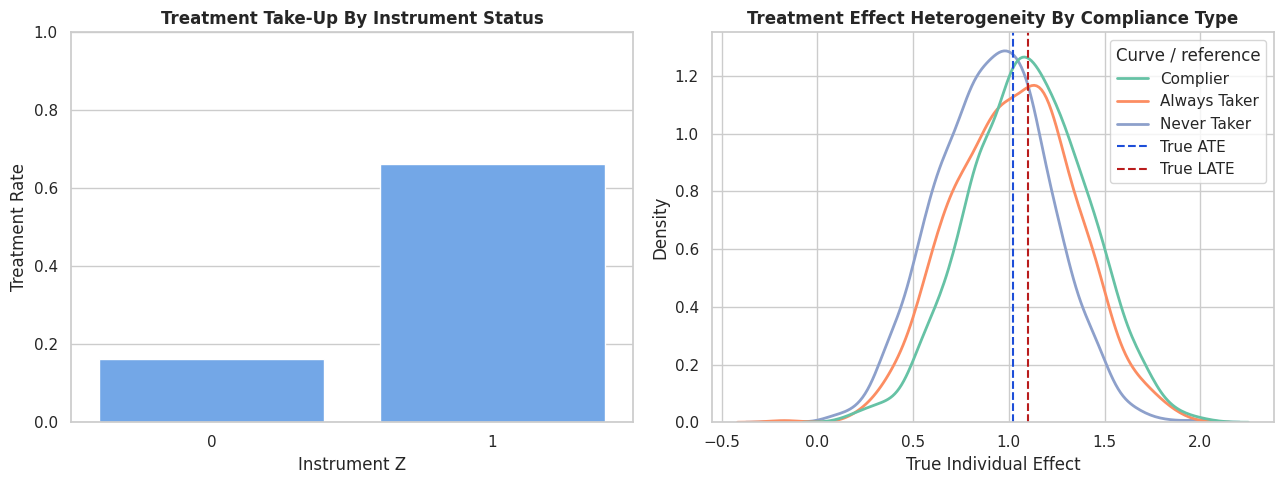

In [8]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

takeup = (
    iivm_df.groupby("encouragement")
    .agg(treatment_rate=("feature_exposure", "mean"), n=("feature_exposure", "size"))
    .reset_index()
)
sns.barplot(data=takeup, x="encouragement", y="treatment_rate", color="#60a5fa", ax=axes[0])
axes[0].set_title("Treatment Take-Up By Instrument Status")
axes[0].set_xlabel("Instrument Z")
axes[0].set_ylabel("Treatment Rate")
axes[0].set_ylim(0, 1)

# Seaborn's automatic hue legend can be overwritten after adding Matplotlib reference lines.
# We draw the KDE curves without an automatic legend, then build one combined legend manually.
compliance_order = ["complier", "always_taker", "never_taker"]
compliance_order = [group for group in compliance_order if group in iivm_df["compliance_type"].unique()]
compliance_palette = dict(zip(compliance_order, sns.color_palette("Set2", n_colors=len(compliance_order))))

sns.kdeplot(
    data=iivm_df,
    x="true_tau",
    hue="compliance_type",
    hue_order=compliance_order,
    palette=compliance_palette,
    common_norm=False,
    linewidth=2,
    legend=False,
    ax=axes[1],
)
axes[1].axvline(TRUE_ATE, color="#1d4ed8", linestyle="--", linewidth=1.5)
axes[1].axvline(TRUE_LATE, color="#b91c1c", linestyle="--", linewidth=1.5)
axes[1].set_title("Treatment Effect Heterogeneity By Compliance Type")
axes[1].set_xlabel("True Individual Effect")

legend_handles = [
    Line2D([0], [0], color=compliance_palette[group], linewidth=2, label=group.replace("_", " ").title())
    for group in compliance_order
]
legend_handles.extend(
    [
        Line2D([0], [0], color="#1d4ed8", linestyle="--", linewidth=1.5, label="True ATE"),
        Line2D([0], [0], color="#b91c1c", linestyle="--", linewidth=1.5, label="True LATE"),
    ]
)
axes[1].legend(handles=legend_handles, title="Curve / reference", frameon=True, loc="best")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_compliance_and_take_up.png", dpi=160, bbox_inches="tight")
plt.show()


The instrument creates a clear treatment-rate difference. The effect distributions show why the local effect is more than a technicality; it can be a meaningfully different causal target.



### Instrument Overlap

The instrument propensity should not be too close to zero or one. If some covariate profiles almost always receive the same instrument status, there is little local comparison for those profiles.

The code below summarizes the true instrument propensity and displays its distribution by observed instrument status.

,diagnostic,value
0,instrument propensity minimum,0.080000
1,instrument propensity p05,0.218420
2,instrument propensity median,0.475840
3,instrument propensity p95,0.741112
4,instrument propensity maximum,0.889678


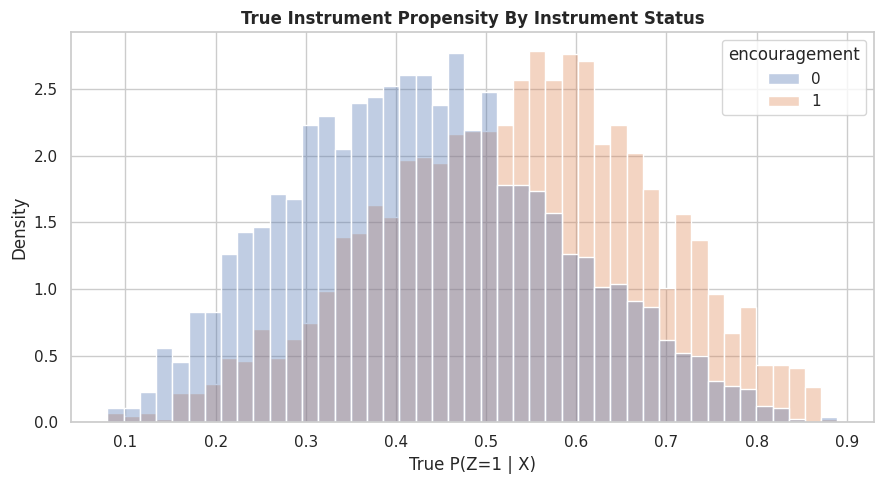

In [9]:
# Build and label the diagnostic visualization for the Instrument Overlap section.
instrument_overlap_summary = pd.DataFrame(
    [
        {"diagnostic": "instrument propensity minimum", "value": float(iivm_df["true_instrument_propensity"].min())},
        {"diagnostic": "instrument propensity p05", "value": float(iivm_df["true_instrument_propensity"].quantile(0.05))},
        {"diagnostic": "instrument propensity median", "value": float(iivm_df["true_instrument_propensity"].median())},
        {"diagnostic": "instrument propensity p95", "value": float(iivm_df["true_instrument_propensity"].quantile(0.95))},
        {"diagnostic": "instrument propensity maximum", "value": float(iivm_df["true_instrument_propensity"].max())},
    ]
)
save_table(instrument_overlap_summary, "instrument_overlap_summary")
display(instrument_overlap_summary)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=iivm_df,
    x="true_instrument_propensity",
    hue="encouragement",
    bins=45,
    stat="density",
    common_norm=False,
    alpha=0.35,
    ax=ax,
)
ax.set_title("True Instrument Propensity By Instrument Status")
ax.set_xlabel("True P(Z=1 | X)")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_instrument_overlap.png", dpi=160, bbox_inches="tight")
plt.show()


The instrument overlap is healthy in this simulation. In real data, poor instrument overlap can make the local effect unstable or limit the population for which the estimate is meaningful.

#### Correlation Screen

The correlation matrix gives a quick view of relationships among outcome, treatment, instrument, compliance probabilities, and controls.

Correlation is not identification. It is just a useful screen before fitting models.

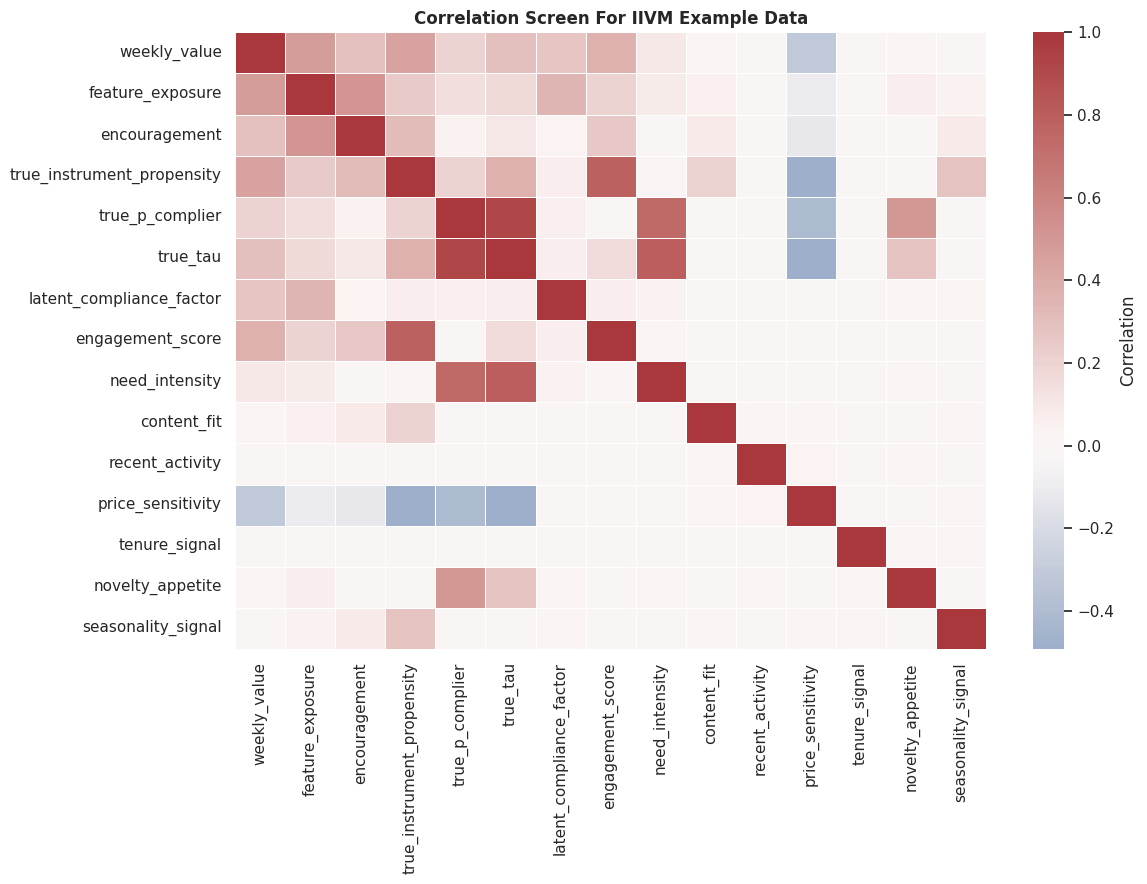

In [10]:
# Build and label the diagnostic visualization for the Correlation Screen section.
corr_cols = [
    "weekly_value",
    "feature_exposure",
    "encouragement",
    "true_instrument_propensity",
    "true_p_complier",
    "true_tau",
    "latent_compliance_factor",
] + feature_cols
corr_matrix = iivm_df[corr_cols].corr()
save_table(corr_matrix.reset_index().rename(columns={"index": "column"}), "design_correlation_matrix")

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    cmap="vlag",
    center=0,
    annot=False,
    linewidths=0.4,
    cbar_kws={"label": "Correlation"},
    ax=ax,
)
ax.set_title("Correlation Screen For IIVM Example Data")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_design_correlation_matrix.png", dpi=160, bbox_inches="tight")
plt.show()


The treatment is related to the latent compliance factor, which is why direct treatment comparisons are biased. The instrument is designed to be usable after adjustment for controls.



#### Baseline Estimators

We compare several simple estimators before fitting DoubleML:

- Difference in means by treatment status.
- OLS adjustment using treatment and observed controls.
- Raw Wald ratio using instrument groups without controls.
- Linear residualized Wald ratio.
- Oracle IIVM ratio using the true nuisance functions.

The oracle estimator is available only in this synthetic notebook.

In [11]:
# Save the artifacts produced by the Baseline Estimators section.
y = iivm_df["weekly_value"].to_numpy()
d = iivm_df["feature_exposure"].to_numpy()
z = iivm_df["encouragement"].to_numpy()
X = iivm_df[feature_cols]

baseline_rows = []
baseline_rows.append(mean_difference_summary(y, d, "Difference in means by treatment", target="direct treatment comparison"))
baseline_rows.append(treatment_ols_summary(iivm_df["weekly_value"], iivm_df[["feature_exposure"] + feature_cols], "feature_exposure", "OLS with raw controls"))
baseline_rows.append(wald_summary(y, d, z, "Raw Wald ratio"))
baseline_rows.append(residualized_wald_summary(y, d, z, X, "Linear residualized Wald ratio"))
baseline_rows.append(
    iivm_ratio_summary(
        y=y,
        d=d,
        z=z,
        g0_hat=iivm_df["true_g0"].to_numpy(),
        g1_hat=iivm_df["true_g1"].to_numpy(),
        m_hat=iivm_df["true_instrument_propensity"].to_numpy(),
        r0_hat=iivm_df["true_r0"].to_numpy(),
        r1_hat=iivm_df["true_r1"].to_numpy(),
        label="Oracle IIVM ratio",
    )
)

baseline_estimates = pd.DataFrame(baseline_rows)
baseline_estimates["true_target"] = np.where(
    baseline_estimates["target"].str.contains("treatment", case=False, na=False),
    TRUE_ATE,
    TRUE_LATE,
)
baseline_estimates.loc[baseline_estimates["estimator"].eq("OLS with raw controls"), "true_target"] = TRUE_ATE
baseline_estimates["bias_vs_target"] = baseline_estimates["theta_hat"] - baseline_estimates["true_target"]
save_table(baseline_estimates, "baseline_estimates")
display(baseline_estimates)


,estimator,target,theta_hat,std_error,ci_95_lower,ci_95_upper,p_value,wald_numerator,wald_denominator,iivm_numerator,iivm_denominator,true_target,bias_vs_target
0,Difference in means by treatment,direct treatment comparison,1.523229,0.040880,1.443103,1.603354,NaN,NaN,NaN,NaN,NaN,1.020535,0.502693
1,OLS with raw controls,observed-control treatment slope,1.223530,0.037648,1.149742,1.297318,1.082914e-231,NaN,NaN,NaN,NaN,1.020535,0.202994
2,Raw Wald ratio,raw Wald LATE-style ratio,1.849634,0.080037,1.692762,2.006506,NaN,0.924632,0.499900,NaN,NaN,1.101928,0.747706
3,Linear residualized Wald ratio,linear residualized Wald ratio,1.178991,0.078897,1.024353,1.333629,NaN,0.124390,0.105505,NaN,NaN,1.101928,0.077064
4,Oracle IIVM ratio,LATE,1.116161,0.064275,0.990182,1.242139,NaN,NaN,NaN,0.527789,0.472861,1.101928,0.014233


Direct treatment comparisons are biased because treatment selection is related to latent compliance factors. The raw Wald ratio is also off because the instrument depends on observed controls. Adjustment matters for the binary IV design.

#### Baseline Estimate Plot

The plot compares baseline estimates against two reference lines: the true ATE and the true local effect.

The local effect is the correct reference for IV-style rows. The ATE is the reference for direct treatment-comparison rows.

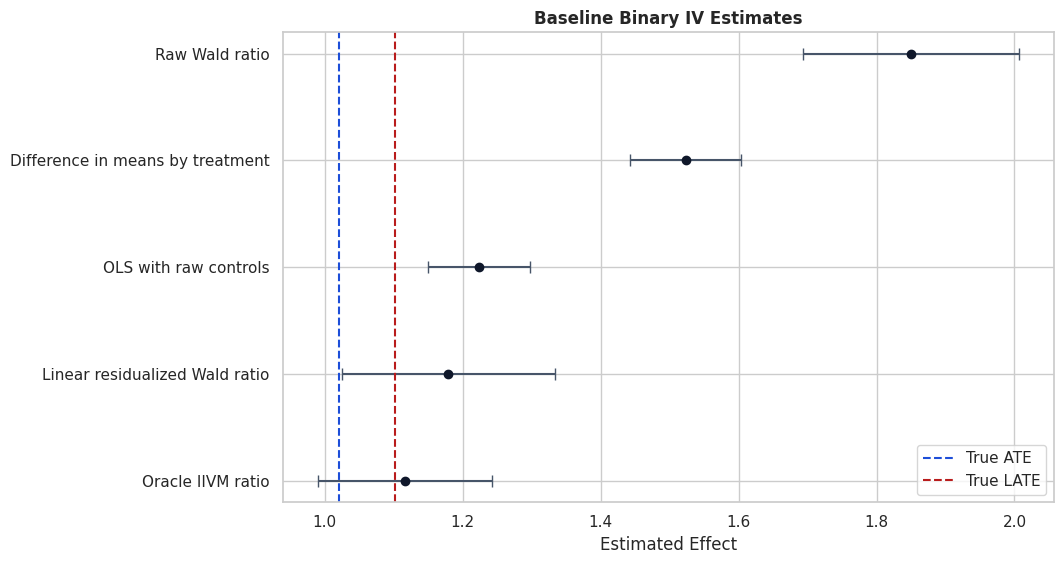

In [12]:
plot_baselines = baseline_estimates.copy().sort_values("theta_hat")
plot_baselines["lower_error"] = plot_baselines["theta_hat"] - plot_baselines["ci_95_lower"]
plot_baselines["upper_error"] = plot_baselines["ci_95_upper"] - plot_baselines["theta_hat"]

fig, ax = plt.subplots(figsize=(10.8, 5.8))
y_pos = np.arange(len(plot_baselines))
ax.errorbar(
    x=plot_baselines["theta_hat"],
    y=y_pos,
    xerr=[plot_baselines["lower_error"], plot_baselines["upper_error"]],
    fmt="o",
    color="#0f172a",
    ecolor="#475569",
    capsize=4,
)
ax.axvline(TRUE_ATE, color="#1d4ed8", linestyle="--", linewidth=1.5, label="True ATE")
ax.axvline(TRUE_LATE, color="#b91c1c", linestyle="--", linewidth=1.5, label="True LATE")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_baselines["estimator"])
ax.set_xlabel("Estimated Effect")
ax.set_title("Baseline Binary IV Estimates")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_baseline_estimates.png", dpi=160, bbox_inches="tight")
plt.show()


The figure shows why IIVM has its own notebook. Binary IV estimates answer a local instrument-induced question, not the same question as a binary-treatment IRM ATE.

### Nuisance Learners

`DoubleMLIIVM` uses three nuisance learner roles:

- `ml_g`: outcome regression as a function of instrument status and controls.
- `ml_m`: instrument propensity classifier, `P(Z=1 | X)`.
- `ml_r`: treatment take-up classifier, `P(D=1 | Z, X)`.

We compare a linear/logistic baseline with gradient boosting. The outcome nuisance is continuous, while the instrument and treatment nuisances are classifiers.

In [13]:
# Fit or evaluate the model objects used in the Nuisance Learners section.
linear_outcome_learner = make_pipeline(
    StandardScaler(),
    LassoCV(cv=3, random_state=RANDOM_STATE, max_iter=5_000),
)
linear_instrument_learner = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(cv=3, max_iter=2_000, scoring="neg_log_loss", random_state=RANDOM_STATE),
)
linear_treatment_learner = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(cv=3, max_iter=2_000, scoring="neg_log_loss", random_state=RANDOM_STATE),
)

hgb_outcome_learner = HistGradientBoostingRegressor(
    max_iter=180,
    learning_rate=0.05,
    max_leaf_nodes=24,
    l2_regularization=0.001,
    random_state=RANDOM_STATE,
)
hgb_instrument_learner = HistGradientBoostingClassifier(
    max_iter=180,
    learning_rate=0.05,
    max_leaf_nodes=24,
    l2_regularization=0.001,
    random_state=RANDOM_STATE,
)
hgb_treatment_learner = HistGradientBoostingClassifier(
    max_iter=180,
    learning_rate=0.05,
    max_leaf_nodes=24,
    l2_regularization=0.001,
    random_state=RANDOM_STATE,
)

learner_catalog = pd.DataFrame(
    [
        {"learner_name": "Linear/logistic nuisance set", "use_case": "Transparent baseline; may underfit nonlinear compliance and outcome patterns."},
        {"learner_name": "Gradient-boosted nuisance set", "use_case": "Captures nonlinear instrument, treatment, and outcome nuisance functions."},
    ]
)
save_table(learner_catalog, "learner_catalog")
display(learner_catalog)


,learner_name,use_case
0,Linear/logistic nuisance set,Transparent baseline; may underfit nonlinear compliance and outcome patterns.
1,Gradient-boosted nuisance set,"Captures nonlinear instrument, treatment, and outcome nuisance functions."


The nuisance learners estimate the components of the ratio score. The final target remains the local treatment effect, not the predictive performance itself.

The causal implication is indirect but important: these diagnostics tell us whether the modeling stage is stable enough to support the causal estimate.
<!-- result-implication-expanded -->


#### Manual Cross-Fitted IIVM

Before fitting DoubleML, we manually compute the cross-fitted IIVM ratio.

The numerator estimates how the instrument changes the outcome after adjusting for controls. The denominator estimates how the instrument changes treatment after adjusting for controls. Their ratio estimates the local treatment effect.

In [14]:
# Save the artifacts produced by the Manual Cross-Fitted IIVM section.
manual_g0_hat, manual_g1_hat, manual_m_hat, manual_r0_hat, manual_r1_hat = crossfit_iivm_nuisances(
    X=X,
    y=y,
    d=d,
    z=z,
    outcome_learner=hgb_outcome_learner,
    instrument_learner=hgb_instrument_learner,
    treatment_learner=hgb_treatment_learner,
    n_splits=5,
    random_state=RANDOM_STATE,
)

manual_iivm_estimate = pd.DataFrame(
    [
        iivm_ratio_summary(
            y=y,
            d=d,
            z=z,
            g0_hat=manual_g0_hat,
            g1_hat=manual_g1_hat,
            m_hat=manual_m_hat,
            r0_hat=manual_r0_hat,
            r1_hat=manual_r1_hat,
            label="Manual cross-fitted IIVM",
        )
    ]
)
manual_iivm_estimate["true_target"] = TRUE_LATE
manual_iivm_estimate["bias_vs_target"] = manual_iivm_estimate["theta_hat"] - TRUE_LATE
save_table(manual_iivm_estimate, "manual_crossfit_iivm_estimate")
display(manual_iivm_estimate)


,estimator,target,theta_hat,std_error,ci_95_lower,ci_95_upper,p_value,iivm_numerator,iivm_denominator,true_target,bias_vs_target
0,Manual cross-fitted IIVM,LATE,1.185114,0.081281,1.025803,1.344424,NaN,0.549075,0.46331,1.101928,0.083186


The manual cross-fitted ratio is the IIVM idea in plain Python. DoubleML automates the same structure with score management, inference, repeated splits, and diagnostics.

### Manual Nuisance Quality

Since this is synthetic data, we can compare cross-fitted nuisance predictions to the true nuisance functions.

Real applications cannot do this. They should use out-of-fold loss, instrument overlap, first-stage diagnostics, and design evidence.

In [15]:
# Save the artifacts produced by the Manual Nuisance Quality section.
manual_nuisance_quality = pd.DataFrame(
    [
        {
            "nuisance": "g0(X) = E[Y | Z=0, X]",
            "rmse_vs_truth": rmse(iivm_df["true_g0"], manual_g0_hat),
            "mae_vs_truth": float(mean_absolute_error(iivm_df["true_g0"], manual_g0_hat)),
            "correlation_vs_truth": float(np.corrcoef(iivm_df["true_g0"], manual_g0_hat)[0, 1]),
        },
        {
            "nuisance": "g1(X) = E[Y | Z=1, X]",
            "rmse_vs_truth": rmse(iivm_df["true_g1"], manual_g1_hat),
            "mae_vs_truth": float(mean_absolute_error(iivm_df["true_g1"], manual_g1_hat)),
            "correlation_vs_truth": float(np.corrcoef(iivm_df["true_g1"], manual_g1_hat)[0, 1]),
        },
        {
            "nuisance": "m(X) = P(Z=1 | X)",
            "rmse_vs_truth": rmse(iivm_df["true_instrument_propensity"], manual_m_hat),
            "mae_vs_truth": float(mean_absolute_error(iivm_df["true_instrument_propensity"], manual_m_hat)),
            "correlation_vs_truth": float(np.corrcoef(iivm_df["true_instrument_propensity"], manual_m_hat)[0, 1]),
            "auc_for_instrument": float(roc_auc_score(z, manual_m_hat)),
            "log_loss_for_instrument": float(log_loss(z, manual_m_hat)),
        },
        {
            "nuisance": "r0(X) = P(D=1 | Z=0, X)",
            "rmse_vs_truth": rmse(iivm_df["true_r0"], manual_r0_hat),
            "mae_vs_truth": float(mean_absolute_error(iivm_df["true_r0"], manual_r0_hat)),
            "correlation_vs_truth": float(np.corrcoef(iivm_df["true_r0"], manual_r0_hat)[0, 1]),
        },
        {
            "nuisance": "r1(X) = P(D=1 | Z=1, X)",
            "rmse_vs_truth": rmse(iivm_df["true_r1"], manual_r1_hat),
            "mae_vs_truth": float(mean_absolute_error(iivm_df["true_r1"], manual_r1_hat)),
            "correlation_vs_truth": float(np.corrcoef(iivm_df["true_r1"], manual_r1_hat)[0, 1]),
        },
    ]
)
save_table(manual_nuisance_quality, "manual_nuisance_quality")
display(manual_nuisance_quality)


,nuisance,rmse_vs_truth,mae_vs_truth,correlation_vs_truth,auc_for_instrument,log_loss_for_instrument
0,"g0(X) = E[Y | Z=0, X]",0.432298,0.332140,0.893133,NaN,NaN
1,"g1(X) = E[Y | Z=1, X]",0.472638,0.360051,0.906499,NaN,NaN
2,m(X) = P(Z=1 | X),0.115957,0.092211,0.807057,0.649979,0.668999
3,"r0(X) = P(D=1 | Z=0, X)",0.117598,0.094287,0.394385,NaN,NaN
4,"r1(X) = P(D=1 | Z=1, X)",0.155754,0.126420,0.674081,NaN,NaN


The nuisance predictions are useful but imperfect. The local ratio estimate is designed to be less sensitive to small nuisance errors, but weak nuisance quality can still create instability.



#### Manual First-Stage Diagnostics

The denominator of the IIVM ratio is the estimated instrument effect on treatment. This is the first stage.

If the denominator is close to zero, the local effect becomes unstable. The code below summarizes the manual cross-fitted first stage.

,diagnostic,value
0,mean first stage r1_hat - r0_hat,0.505220
1,first-stage p05,0.089992
2,first-stage median,0.528812
3,first-stage p95,0.846567
4,share with negative estimated first stage,0.023400


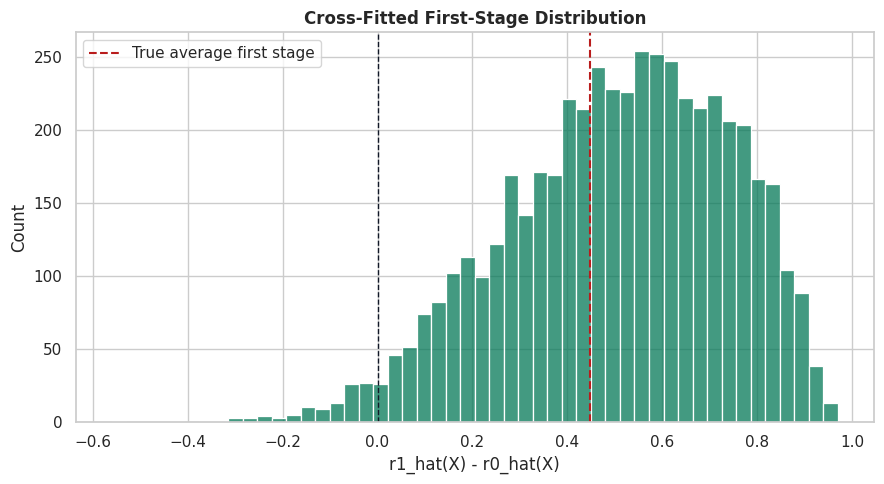

In [16]:
# Build and label the diagnostic visualization for the Manual First-Stage Diagnostics section.
manual_first_stage = manual_r1_hat - manual_r0_hat
manual_first_stage_summary = pd.DataFrame(
    [
        {
            "diagnostic": "mean first stage r1_hat - r0_hat",
            "value": float(np.mean(manual_first_stage)),
        },
        {"diagnostic": "first-stage p05", "value": float(np.quantile(manual_first_stage, 0.05))},
        {"diagnostic": "first-stage median", "value": float(np.median(manual_first_stage))},
        {"diagnostic": "first-stage p95", "value": float(np.quantile(manual_first_stage, 0.95))},
        {"diagnostic": "share with negative estimated first stage", "value": float(np.mean(manual_first_stage < 0))},
    ]
)
save_table(manual_first_stage_summary, "manual_first_stage_summary")
display(manual_first_stage_summary)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(manual_first_stage, bins=50, color="#047857", alpha=0.75, ax=ax)
ax.axvline(0, color="#111827", linestyle="--", linewidth=1)
ax.axvline(TRUE_FIRST_STAGE, color="#b91c1c", linestyle="--", linewidth=1.5, label="True average first stage")
ax.set_title("Cross-Fitted First-Stage Distribution")
ax.set_xlabel("r1_hat(X) - r0_hat(X)")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_manual_first_stage_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


The first stage is mostly positive and comfortably away from zero on average. That fits the monotonic noncompliance design used in the simulation.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->




#### Build the DoubleML Data Object

`DoubleMLIIVM` needs a `DoubleMLData` object with:

- outcome column `weekly_value`;
- treatment column `feature_exposure`;
- instrument column `encouragement`;
- observed controls.

The hidden compliance and potential-outcome columns are excluded.

In [17]:
dml_data = DoubleMLData(
    iivm_df[["weekly_value", "feature_exposure", "encouragement"] + feature_cols],
    y_col="weekly_value",
    d_cols="feature_exposure",
    x_cols=feature_cols,
    z_cols="encouragement",
)

backend_summary = pd.DataFrame(
    [
        {"role": "outcome", "columns": dml_data.y_col},
        {"role": "treatment", "columns": ", ".join(dml_data.d_cols)},
        {"role": "instrument", "columns": ", ".join(dml_data.z_cols)},
        {"role": "controls", "columns": ", ".join(dml_data.x_cols)},
        {"role": "number_of_observations", "columns": str(dml_data.n_obs)},
    ]
)
save_table(backend_summary, "doublemldata_backend_summary")
display(backend_summary)


,role,columns
0,outcome,weekly_value
1,treatment,feature_exposure
2,instrument,encouragement
3,controls,"engagement_score, need_intensity, content_fit, recent_activity, price_sensitivity, tenure_signal, novelty_appetite, seasonality_signal"
4,number_of_observations,5000


The instrument role is explicit through `z_cols`. This is the key data-backend difference between IRM and IIVM.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->


#### Fit `DoubleMLIIVM`

We now fit two IIVM specifications:

- a linear/logistic nuisance baseline;
- a gradient-boosted nuisance model.

Both use the default `score="LATE"` and five-fold cross-fitting.

In [18]:
# Fit or evaluate the model objects used in the Fit `DoubleMLIIVM` section.
iivm_model_specs = {
    "Linear nuisance IIVM": {
        "ml_g": linear_outcome_learner,
        "ml_m": linear_instrument_learner,
        "ml_r": linear_treatment_learner,
    },
    "Gradient boosting nuisance IIVM": {
        "ml_g": hgb_outcome_learner,
        "ml_m": hgb_instrument_learner,
        "ml_r": hgb_treatment_learner,
    },
}

iivm_models = {}
for model_name, spec in iivm_model_specs.items():
    model = DoubleMLIIVM(
        dml_data,
        ml_g=clone(spec["ml_g"]),
        ml_m=clone(spec["ml_m"]),
        ml_r=clone(spec["ml_r"]),
        n_folds=5,
        n_rep=1,
        score="LATE",
    )
    model.fit(store_predictions=True)
    iivm_models[model_name] = model
    print(f"Finished: {model_name}")

iivm_summary_rows = []
for model_name, model in iivm_models.items():
    summary = model.summary.reset_index().rename(columns={"index": "treatment"})
    row = summary.iloc[0].to_dict()
    iivm_summary_rows.append(
        {
            "estimator": model_name,
            "treatment": row["treatment"],
            "theta_hat": row["coef"],
            "std_error": row["std err"],
            "t_stat": row["t"],
            "p_value": row["P>|t|"],
            "ci_95_lower": row["2.5 %"],
            "ci_95_upper": row["97.5 %"],
            "true_target": TRUE_LATE,
            "bias_vs_target": row["coef"] - TRUE_LATE,
        }
    )

iivm_summary = pd.DataFrame(iivm_summary_rows)
save_table(iivm_summary, "doubleml_iivm_summary")
display(iivm_summary)


Finished: Linear nuisance IIVM


Finished: Gradient boosting nuisance IIVM


,estimator,treatment,theta_hat,std_error,t_stat,p_value,ci_95_lower,ci_95_upper,true_target,bias_vs_target
0,Linear nuisance IIVM,feature_exposure,1.164632,0.080412,14.483268,1.545710e-47,1.007027,1.322237,1.101928,0.062704
1,Gradient boosting nuisance IIVM,feature_exposure,1.161802,0.083645,13.889707,7.313355e-44,0.997861,1.325743,1.101928,0.059874


The gradient-boosted model is expected to do better because the synthetic compliance and outcome functions are nonlinear. The linear/logistic model is still useful as a transparent baseline.



#### Compare All Estimators

This table combines direct treatment comparisons, Wald-style baselines, the manual cross-fitted IIVM estimate, and DoubleML estimates.

The key comparison is whether an estimator targets the full-population treatment effect or the local instrument-induced effect.

In [19]:
all_estimates = pd.concat(
    [
        baseline_estimates[["estimator", "target", "theta_hat", "std_error", "ci_95_lower", "ci_95_upper", "p_value", "true_target", "bias_vs_target"]],
        manual_iivm_estimate[["estimator", "target", "theta_hat", "std_error", "ci_95_lower", "ci_95_upper", "p_value", "true_target", "bias_vs_target"]],
        iivm_summary.assign(target="LATE")[["estimator", "target", "theta_hat", "std_error", "ci_95_lower", "ci_95_upper", "p_value", "true_target", "bias_vs_target"]],
    ],
    ignore_index=True,
)
all_estimates["abs_bias_vs_target"] = all_estimates["bias_vs_target"].abs()
save_table(all_estimates, "all_estimator_comparison")
display(all_estimates.sort_values("abs_bias_vs_target"))

,estimator,target,theta_hat,std_error,ci_95_lower,ci_95_upper,p_value,true_target,bias_vs_target,abs_bias_vs_target
4,Oracle IIVM ratio,LATE,1.116161,0.064275,0.990182,1.242139,NaN,1.101928,0.014233,0.014233
7,Gradient boosting nuisance IIVM,LATE,1.161802,0.083645,0.997861,1.325743,7.313355e-44,1.101928,0.059874,0.059874
6,Linear nuisance IIVM,LATE,1.164632,0.080412,1.007027,1.322237,1.545710e-47,1.101928,0.062704,0.062704
3,Linear residualized Wald ratio,linear residualized Wald ratio,1.178991,0.078897,1.024353,1.333629,NaN,1.101928,0.077064,0.077064
5,Manual cross-fitted IIVM,LATE,1.185114,0.081281,1.025803,1.344424,NaN,1.101928,0.083186,0.083186
1,OLS with raw controls,observed-control treatment slope,1.223530,0.037648,1.149742,1.297318,1.082914e-231,1.020535,0.202994,0.202994
0,Difference in means by treatment,direct treatment comparison,1.523229,0.040880,1.443103,1.603354,NaN,1.020535,0.502693,0.502693
2,Raw Wald ratio,raw Wald LATE-style ratio,1.849634,0.080037,1.692762,2.006506,NaN,1.101928,0.747706,0.747706


The adjusted local-effect estimators are much closer to the true local target than direct treatment comparisons. The table also shows why the ATE and local target should not be mixed casually.

#### Estimate Comparison Plot

The figure compares estimates with confidence intervals. The blue line marks the true ATE. The red line marks the true local effect.

IIVM rows should be judged against the red line, not the blue line.

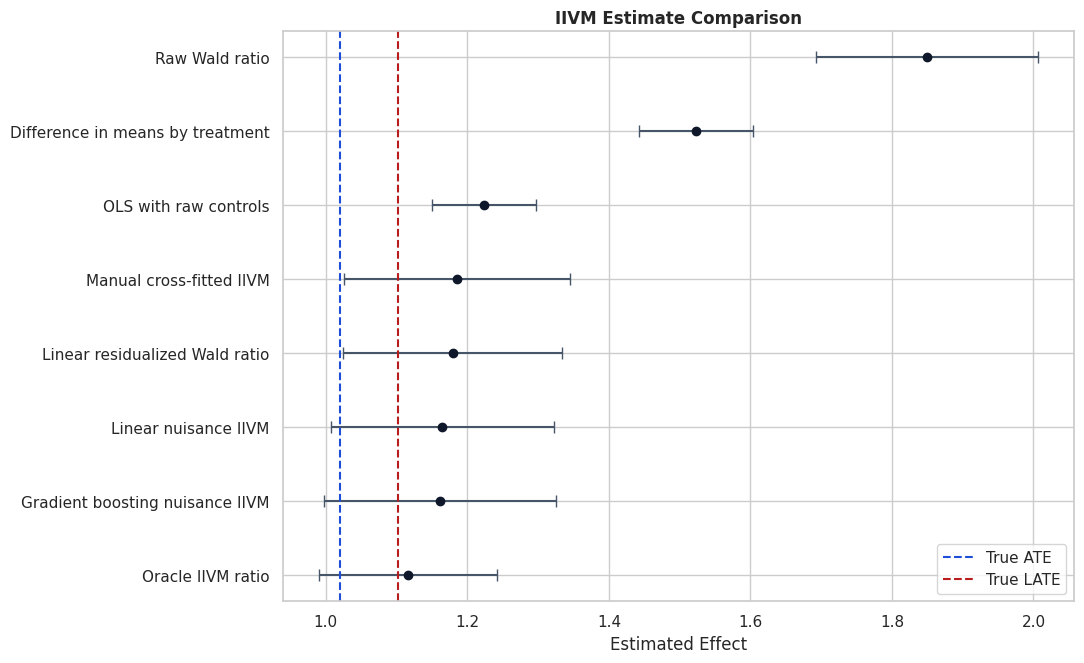

In [20]:
plot_estimates = all_estimates.copy().sort_values("theta_hat")
plot_estimates["lower_error"] = plot_estimates["theta_hat"] - plot_estimates["ci_95_lower"]
plot_estimates["upper_error"] = plot_estimates["ci_95_upper"] - plot_estimates["theta_hat"]

fig, ax = plt.subplots(figsize=(11, 6.8))
y_pos = np.arange(len(plot_estimates))
ax.errorbar(
    x=plot_estimates["theta_hat"],
    y=y_pos,
    xerr=[plot_estimates["lower_error"], plot_estimates["upper_error"]],
    fmt="o",
    color="#0f172a",
    ecolor="#475569",
    capsize=4,
)
ax.axvline(TRUE_ATE, color="#1d4ed8", linestyle="--", linewidth=1.5, label="True ATE")
ax.axvline(TRUE_LATE, color="#b91c1c", linestyle="--", linewidth=1.5, label="True LATE")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_estimates["estimator"])
ax.set_xlabel("Estimated Effect")
ax.set_title("IIVM Estimate Comparison")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_iivm_estimate_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


The plot reinforces the main lesson: binary IV is about the treatment effect for the instrument-induced margin, not necessarily the whole population.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->




### Nuisance Losses

`evaluate_learners()` reports out-of-fold nuisance losses. For IIVM, the prediction keys are:

- `ml_g0`: outcome nuisance for `Z=0`.
- `ml_g1`: outcome nuisance for `Z=1`.
- `ml_m`: instrument propensity nuisance.
- `ml_r0`: treatment take-up nuisance for `Z=0`.
- `ml_r1`: treatment take-up nuisance for `Z=1`.

These are diagnostics for the nuisance stage, not proofs of instrument validity.

In [21]:
loss_tables = []
for model_name, model in iivm_models.items():
    loss_tables.append(learner_loss_table(model, model_name))

nuisance_losses = pd.concat(loss_tables, ignore_index=True)
save_table(nuisance_losses, "doubleml_nuisance_losses")
display(nuisance_losses)

,model,learner,mean_loss,min_loss,max_loss
0,Linear nuisance IIVM,ml_g0,1.317448,1.317448,1.317448
1,Linear nuisance IIVM,ml_g1,1.356263,1.356263,1.356263
2,Linear nuisance IIVM,ml_m,0.473186,0.473186,0.473186
3,Linear nuisance IIVM,ml_r0,0.365269,0.365269,0.365269
4,Linear nuisance IIVM,ml_r1,0.456292,0.456292,0.456292
5,Gradient boosting nuisance IIVM,ml_g0,1.182640,1.182640,1.182640
6,Gradient boosting nuisance IIVM,ml_g1,1.209827,1.209827,1.209827
7,Gradient boosting nuisance IIVM,ml_m,0.487577,0.487577,0.487577
8,Gradient boosting nuisance IIVM,ml_r0,0.375131,0.375131,0.375131
9,Gradient boosting nuisance IIVM,ml_r1,0.473399,0.473399,0.473399


The loss table helps compare nuisance specifications. It does not answer exclusion, independence, or monotonicity questions.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->


#### Extract DoubleML Predictions

We now extract stored predictions from the gradient-boosted IIVM model.

These predictions let us inspect instrument propensity, treatment take-up, first-stage strength, and outcome nuisance quality.

In [22]:
iivm_hgb = iivm_models["Gradient boosting nuisance IIVM"]
dml_g0_hat = prediction_vector(iivm_hgb, "ml_g0")
dml_g1_hat = prediction_vector(iivm_hgb, "ml_g1")
dml_m_hat = np.clip(prediction_vector(iivm_hgb, "ml_m"), 0.02, 0.98)
dml_r0_hat = np.clip(prediction_vector(iivm_hgb, "ml_r0"), 0.01, 0.99)
dml_r1_hat = np.clip(prediction_vector(iivm_hgb, "ml_r1"), 0.01, 0.99)

dml_prediction_quality = pd.DataFrame(
    [
        {"nuisance": "ml_g0 outcome under Z=0", "rmse_vs_truth": rmse(iivm_df["true_g0"], dml_g0_hat), "mae_vs_truth": float(mean_absolute_error(iivm_df["true_g0"], dml_g0_hat)), "correlation_vs_truth": float(np.corrcoef(iivm_df["true_g0"], dml_g0_hat)[0, 1])},
        {"nuisance": "ml_g1 outcome under Z=1", "rmse_vs_truth": rmse(iivm_df["true_g1"], dml_g1_hat), "mae_vs_truth": float(mean_absolute_error(iivm_df["true_g1"], dml_g1_hat)), "correlation_vs_truth": float(np.corrcoef(iivm_df["true_g1"], dml_g1_hat)[0, 1])},
        {"nuisance": "ml_m instrument propensity", "rmse_vs_truth": rmse(iivm_df["true_instrument_propensity"], dml_m_hat), "mae_vs_truth": float(mean_absolute_error(iivm_df["true_instrument_propensity"], dml_m_hat)), "correlation_vs_truth": float(np.corrcoef(iivm_df["true_instrument_propensity"], dml_m_hat)[0, 1]), "auc_for_instrument": float(roc_auc_score(z, dml_m_hat)), "log_loss_for_instrument": float(log_loss(z, dml_m_hat))},
        {"nuisance": "ml_r0 treatment take-up under Z=0", "rmse_vs_truth": rmse(iivm_df["true_r0"], dml_r0_hat), "mae_vs_truth": float(mean_absolute_error(iivm_df["true_r0"], dml_r0_hat)), "correlation_vs_truth": float(np.corrcoef(iivm_df["true_r0"], dml_r0_hat)[0, 1])},
        {"nuisance": "ml_r1 treatment take-up under Z=1", "rmse_vs_truth": rmse(iivm_df["true_r1"], dml_r1_hat), "mae_vs_truth": float(mean_absolute_error(iivm_df["true_r1"], dml_r1_hat)), "correlation_vs_truth": float(np.corrcoef(iivm_df["true_r1"], dml_r1_hat)[0, 1])},
    ]
)
save_table(dml_prediction_quality, "hgb_nuisance_quality_against_truth")
display(dml_prediction_quality)


,nuisance,rmse_vs_truth,mae_vs_truth,correlation_vs_truth,auc_for_instrument,log_loss_for_instrument
0,ml_g0 outcome under Z=0,0.437759,0.339305,0.890191,NaN,NaN
1,ml_g1 outcome under Z=1,0.475477,0.365548,0.905676,NaN,NaN
2,ml_m instrument propensity,0.115376,0.092329,0.808034,0.645223,0.671921
3,ml_r0 treatment take-up under Z=0,0.114084,0.093139,0.395304,NaN,NaN
4,ml_r1 treatment take-up under Z=1,0.154025,0.125521,0.681571,NaN,NaN


The nuisance predictions are good enough for the teaching design, but not perfect. The first-stage nuisance functions are especially important because they form the denominator of the local-effect ratio.



#### DoubleML First-Stage Diagnostics

The code below summarizes the DoubleML-estimated first stage `r1_hat(X) - r0_hat(X)`.

A strong positive first stage supports relevance and monotonicity-style behavior in the fitted nuisance functions.

In [23]:
dml_first_stage = dml_r1_hat - dml_r0_hat

dml_first_stage_summary = pd.DataFrame(
    [
        {"diagnostic": "mean first stage r1_hat - r0_hat", "value": float(np.mean(dml_first_stage))},
        {"diagnostic": "first-stage p05", "value": float(np.quantile(dml_first_stage, 0.05))},
        {"diagnostic": "first-stage median", "value": float(np.median(dml_first_stage))},
        {"diagnostic": "first-stage p95", "value": float(np.quantile(dml_first_stage, 0.95))},
        {"diagnostic": "share with negative estimated first stage", "value": float(np.mean(dml_first_stage < 0))},
        {"diagnostic": "true average first stage", "value": TRUE_FIRST_STAGE},
    ]
)
save_table(dml_first_stage_summary, "doubleml_first_stage_summary")
display(dml_first_stage_summary)


,diagnostic,value
0,mean first stage r1_hat - r0_hat,0.512196
1,first-stage p05,0.098626
2,first-stage median,0.535449
3,first-stage p95,0.848507
4,share with negative estimated first stage,0.019800
5,true average first stage,0.447774


The estimated first stage is positive on average. A large share of negative estimated first stages would be a warning sign for monotonicity, learner instability, or weak local treatment movement.



#### First-Stage and Propensity Plots

The left panel shows the estimated first-stage distribution. The right panel shows the estimated instrument propensity by observed instrument status.

Together these plots check relevance and instrument overlap.

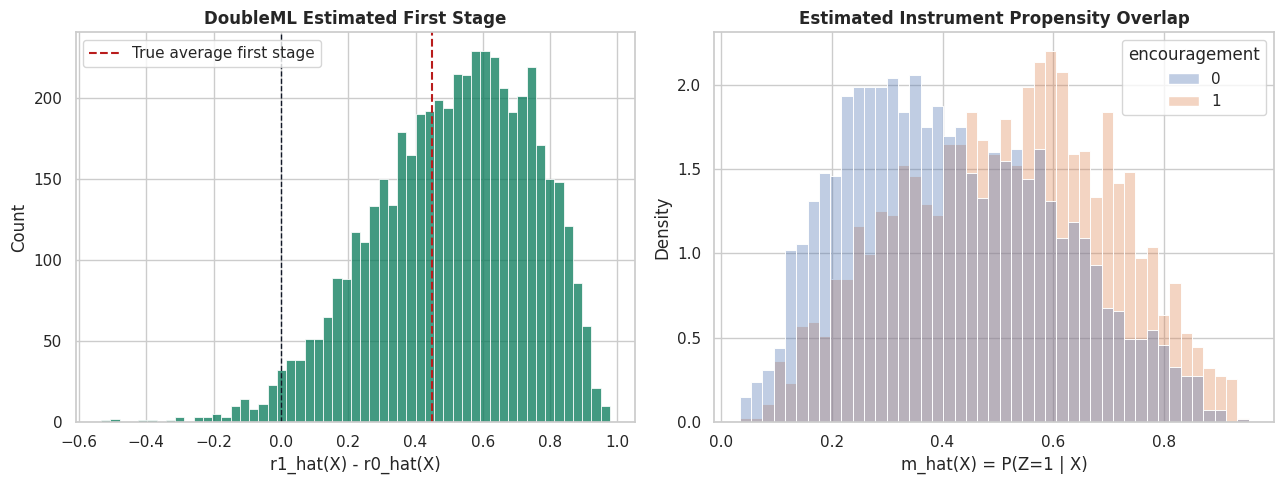

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(dml_first_stage, bins=55, color="#047857", alpha=0.75, ax=axes[0])
axes[0].axvline(0, color="#111827", linestyle="--", linewidth=1)
axes[0].axvline(TRUE_FIRST_STAGE, color="#b91c1c", linestyle="--", linewidth=1.5, label="True average first stage")
axes[0].set_title("DoubleML Estimated First Stage")
axes[0].set_xlabel("r1_hat(X) - r0_hat(X)")
axes[0].legend()

propensity_plot_df = pd.DataFrame({"instrument_propensity": dml_m_hat, "encouragement": z})
sns.histplot(
    data=propensity_plot_df,
    x="instrument_propensity",
    hue="encouragement",
    bins=45,
    stat="density",
    common_norm=False,
    alpha=0.35,
    ax=axes[1],
)
axes[1].set_title("Estimated Instrument Propensity Overlap")
axes[1].set_xlabel("m_hat(X) = P(Z=1 | X)")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_first_stage_and_instrument_overlap.png", dpi=160, bbox_inches="tight")
plt.show()


The first-stage distribution is mostly positive and the instrument propensity has adequate overlap. These are necessary diagnostics, not sufficient proof of IV validity.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->




#### Visual Nuisance Diagnostics

The next figure compares DoubleML's gradient-boosted nuisance predictions with true synthetic nuisance functions.

In real data, this truth comparison is not possible. The analogous workflow is to inspect out-of-fold losses, calibration, overlap, and first-stage stability.

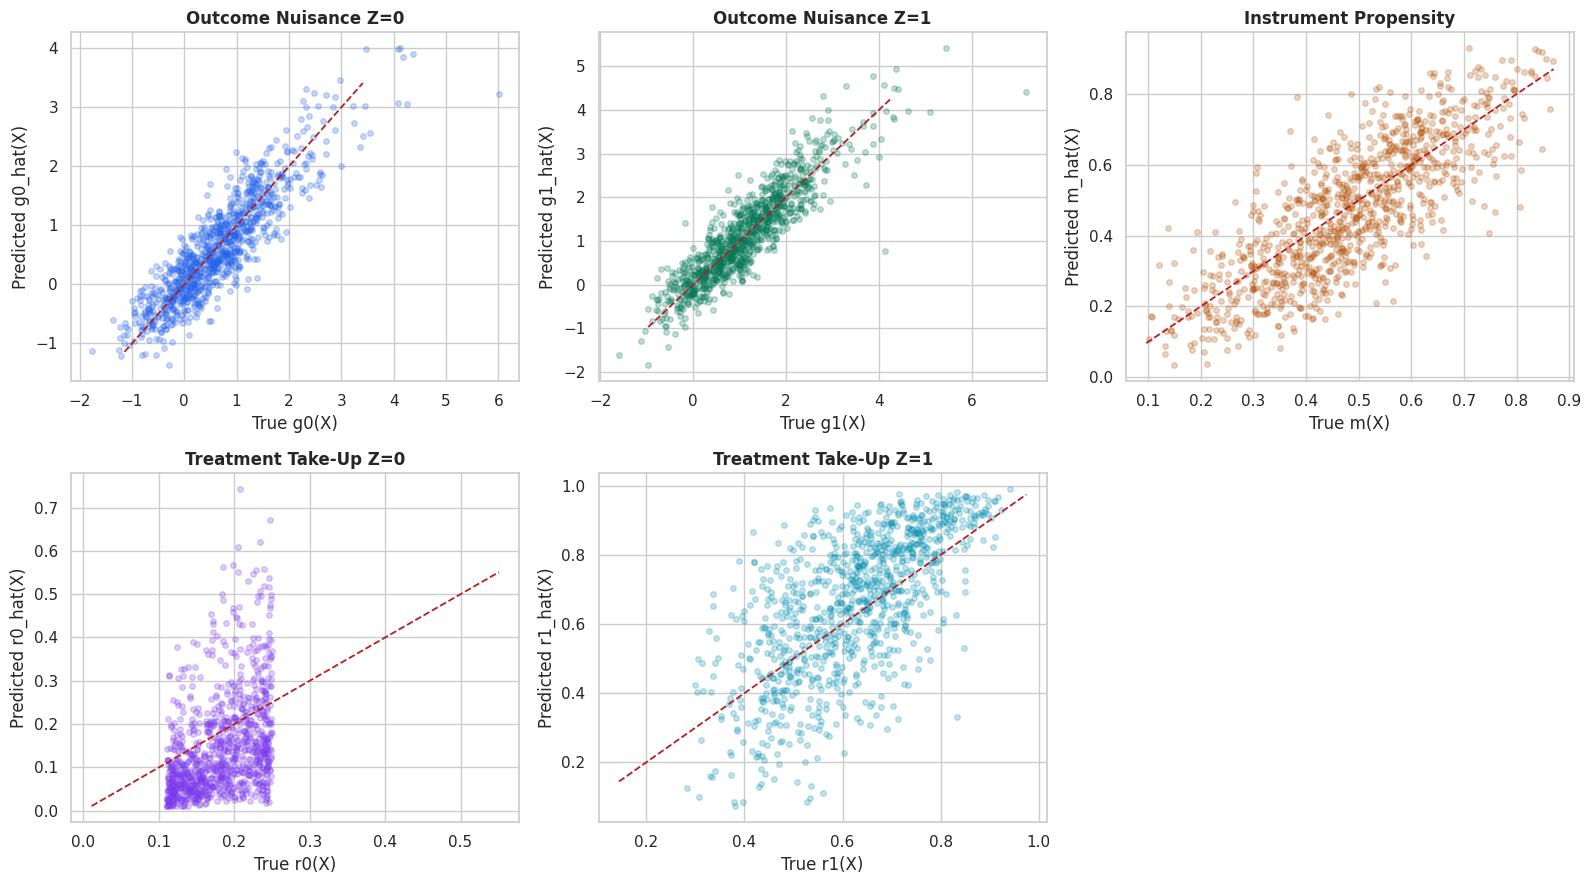

In [25]:
sample_idx = iivm_df.sample(1_000, random_state=RANDOM_STATE).index

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_specs = [
    (iivm_df["true_g0"].to_numpy(), dml_g0_hat, "Outcome Nuisance Z=0", "True g0(X)", "Predicted g0_hat(X)", "#2563eb"),
    (iivm_df["true_g1"].to_numpy(), dml_g1_hat, "Outcome Nuisance Z=1", "True g1(X)", "Predicted g1_hat(X)", "#047857"),
    (iivm_df["true_instrument_propensity"].to_numpy(), dml_m_hat, "Instrument Propensity", "True m(X)", "Predicted m_hat(X)", "#b45309"),
    (iivm_df["true_r0"].to_numpy(), dml_r0_hat, "Treatment Take-Up Z=0", "True r0(X)", "Predicted r0_hat(X)", "#7c3aed"),
    (iivm_df["true_r1"].to_numpy(), dml_r1_hat, "Treatment Take-Up Z=1", "True r1(X)", "Predicted r1_hat(X)", "#0891b2"),
]

for ax, (truth, pred, title, xlabel, ylabel, color) in zip(axes.ravel(), plot_specs):
    ax.scatter(truth[sample_idx], pred[sample_idx], alpha=0.25, s=16, color=color)
    lower = min(np.quantile(truth, 0.01), np.quantile(pred, 0.01))
    upper = max(np.quantile(truth, 0.99), np.quantile(pred, 0.99))
    ax.plot([lower, upper], [lower, upper], color="#b91c1c", linestyle="--", linewidth=1.3)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

axes.ravel()[-1].axis("off")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_doubleml_nuisance_prediction_quality.png", dpi=160, bbox_inches="tight")
plt.show()


The nuisance plots show the model captures the main patterns but smooths some extremes. That is normal for finite-sample machine-learning nuisance estimation.

The causal implication is indirect but important: these diagnostics tell us whether the modeling stage is stable enough to support the causal estimate.
<!-- result-implication-expanded -->


#### Score Contributions

DoubleML stores orthogonal score contributions in `psi`. Large tails can signal influential observations, unstable instrument propensities, or weak first-stage regions.

The code below summarizes and plots score contributions from the main gradient-boosted IIVM fit.

,mean,std,p01,p05,median,p95,p99
0,-2.273737e-17,2.693352,-7.138554,-4.042699,-0.002868,3.905708,7.274044


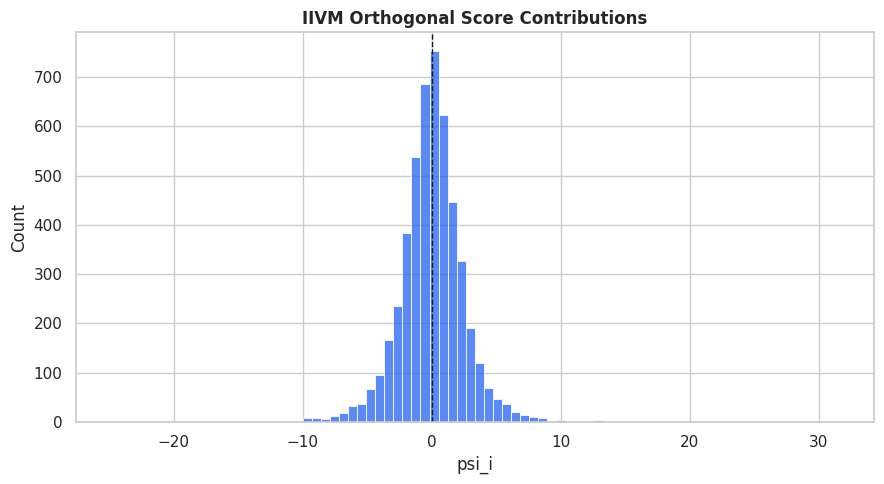

In [26]:
# Build and label the diagnostic visualization for the Score Contributions section.
psi_values = np.asarray(iivm_hgb.psi)[:, 0, 0]
psi_summary = pd.DataFrame(
    [
        {
            "mean": float(np.mean(psi_values)),
            "std": float(np.std(psi_values, ddof=1)),
            "p01": float(np.quantile(psi_values, 0.01)),
            "p05": float(np.quantile(psi_values, 0.05)),
            "median": float(np.median(psi_values)),
            "p95": float(np.quantile(psi_values, 0.95)),
            "p99": float(np.quantile(psi_values, 0.99)),
        }
    ]
)
save_table(psi_summary, "orthogonal_score_summary")
display(psi_summary)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(psi_values, bins=80, color="#2563eb", alpha=0.75, ax=ax)
ax.axvline(0, color="#111827", linewidth=1, linestyle="--")
ax.set_title("IIVM Orthogonal Score Contributions")
ax.set_xlabel("psi_i")
ax.set_ylabel("Count")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_orthogonal_score_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


The score is centered near zero at the fitted estimate. The tails are moderate for this well-behaved teaching design.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Bootstrap Confidence Interval

DoubleML can compute bootstrap confidence intervals. We run a moderate bootstrap for the main gradient-boosted IIVM model.

As always, bootstrap uncertainty does not validate the instrument assumptions.

In [27]:
iivm_hgb.bootstrap(method="normal", n_rep_boot=500)
bootstrap_ci = iivm_hgb.confint(joint=False, level=0.95).reset_index().rename(columns={"index": "treatment"})
bootstrap_ci["estimator"] = "Gradient boosting nuisance IIVM bootstrap"
save_table(bootstrap_ci, "hgb_bootstrap_confidence_interval")
display(bootstrap_ci)

,treatment,2.5 %,97.5 %,estimator
0,feature_exposure,0.997861,1.325743,Gradient boosting nuisance IIVM bootstrap


The bootstrap interval quantifies sampling uncertainty for the local effect under the fitted design. It should be reported with first-stage and instrument-validity discussion.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->




#### Repeated Sample Splitting

Cross-fitted estimates can move with different fold splits. Repeated sample splitting checks numerical stability.

The code below uses a slightly lighter gradient-boosting configuration so the check remains practical.

In [28]:
# Fit or evaluate the model objects used in the Repeated Sample Splitting section.
repeated_outcome_learner = HistGradientBoostingRegressor(
    max_iter=120,
    learning_rate=0.06,
    max_leaf_nodes=22,
    l2_regularization=0.001,
    random_state=RANDOM_STATE,
)
repeated_instrument_learner = HistGradientBoostingClassifier(
    max_iter=120,
    learning_rate=0.06,
    max_leaf_nodes=22,
    l2_regularization=0.001,
    random_state=RANDOM_STATE,
)
repeated_treatment_learner = HistGradientBoostingClassifier(
    max_iter=120,
    learning_rate=0.06,
    max_leaf_nodes=22,
    l2_regularization=0.001,
    random_state=RANDOM_STATE,
)

iivm_repeated = DoubleMLIIVM(
    dml_data,
    ml_g=clone(repeated_outcome_learner),
    ml_m=clone(repeated_instrument_learner),
    ml_r=clone(repeated_treatment_learner),
    n_folds=5,
    n_rep=5,
    score="LATE",
)
iivm_repeated.fit(store_predictions=False)

split_stability = pd.DataFrame(
    {
        "repetition": np.arange(1, iivm_repeated.all_coef.shape[1] + 1),
        "theta_hat": iivm_repeated.all_coef[0],
        "std_error": iivm_repeated.all_se[0],
    }
)
split_stability["true_late"] = TRUE_LATE
split_stability["bias_vs_true_late"] = split_stability["theta_hat"] - TRUE_LATE
save_table(split_stability, "repeated_sample_split_stability")
display(split_stability)


,repetition,theta_hat,std_error,true_late,bias_vs_true_late
0,1,1.132234,0.078785,1.101928,0.030307
1,2,1.089230,0.079997,1.101928,-0.012698
2,3,1.161383,0.078886,1.101928,0.059456
3,4,1.152490,0.076863,1.101928,0.050562
4,5,1.140194,0.077520,1.101928,0.038266


The repeated estimates should be reasonably close. If they jump around, first-stage instability or nuisance-model sensitivity needs attention.

The causal implication is indirect but important: these diagnostics tell us whether the modeling stage is stable enough to support the causal estimate.
<!-- result-implication-expanded -->




#### Split Stability Plot

The next figure shows repeated-split local-effect estimates against the true synthetic local effect.

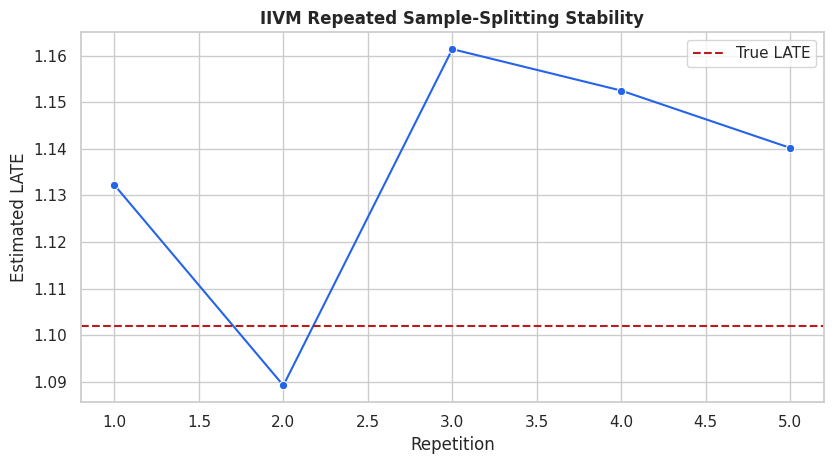

In [29]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.lineplot(data=split_stability, x="repetition", y="theta_hat", marker="o", color="#2563eb", ax=ax)
ax.axhline(TRUE_LATE, color="#b91c1c", linestyle="--", linewidth=1.5, label="True LATE")
ax.set_title("IIVM Repeated Sample-Splitting Stability")
ax.set_xlabel("Repetition")
ax.set_ylabel("Estimated LATE")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_repeated_split_stability.png", dpi=160, bbox_inches="tight")
plt.show()

The estimate is stable across repeated splits in this synthetic design. That supports numerical reliability, not instrument validity by itself.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->




#### Subgroup Assumption Variants

`DoubleMLIIVM` has a `subgroups` argument for designs where always-takers or never-takers are known to be absent.

Our synthetic data contains both always-takers and never-takers. The default setting is therefore the right one. The next cell fits alternative subgroup restrictions to show that incorrect compliance restrictions can change the estimate.

In [30]:
# Fit or evaluate the model objects used in the Subgroup Assumption Variants section.
subgroup_specs = {
    "Default: always and never possible": None,
    "Assume no always-takers": {"always_takers": False, "never_takers": True},
    "Assume no never-takers": {"always_takers": True, "never_takers": False},
    "Assume only compliers": {"always_takers": False, "never_takers": False},
}

subgroup_rows = []
for label, subgroup_config in subgroup_specs.items():
    model = DoubleMLIIVM(
        dml_data,
        ml_g=clone(repeated_outcome_learner),
        ml_m=clone(repeated_instrument_learner),
        ml_r=clone(repeated_treatment_learner),
        n_folds=5,
        n_rep=1,
        score="LATE",
        subgroups=subgroup_config,
    )
    model.fit(store_predictions=False)
    row = model.summary.reset_index().rename(columns={"index": "treatment"}).iloc[0]
    subgroup_rows.append(
        {
            "subgroup_assumption": label,
            "theta_hat": row["coef"],
            "std_error": row["std err"],
            "ci_95_lower": row["2.5 %"],
            "ci_95_upper": row["97.5 %"],
            "true_late": TRUE_LATE,
            "bias_vs_true_late": row["coef"] - TRUE_LATE,
        }
    )

subgroup_comparison = pd.DataFrame(subgroup_rows)
save_table(subgroup_comparison, "subgroup_assumption_comparison")
display(subgroup_comparison)


,subgroup_assumption,theta_hat,std_error,ci_95_lower,ci_95_upper,true_late,bias_vs_true_late
0,Default: always and never possible,1.106915,0.075302,0.959326,1.254504,1.101928,0.004987
1,Assume no always-takers,1.150559,0.077399,0.998859,1.302259,1.101928,0.048632
2,Assume no never-takers,1.246378,0.084706,1.080358,1.412398,1.101928,0.144450
3,Assume only compliers,1.241493,0.084178,1.076507,1.406479,1.101928,0.139565


The subgroup variants are not interchangeable. Use them only when the design genuinely rules out specific compliance types.

The table is useful because it compresses the evidence into a form that can be compared, audited, and tied back to the causal question.
<!-- result-implication-expanded -->




#### First-Stage Stress Test

A weak instrument creates a small denominator in the IIVM ratio. Even with perfect nuisance functions, weak first stages inflate uncertainty and can make estimates unstable.

This synthetic stress test changes only the complier share and uses oracle nuisance functions so the first-stage issue is isolated.

In [31]:
# Save the artifacts produced by the First-Stage Stress Test section.
weak_rows = []
base_tau = true_tau.to_numpy()
base_mu0 = true_mu0.to_numpy()
base_m = true_instrument_propensity.to_numpy()
base_z = encouragement
base_noise = outcome_noise

for multiplier in [0.25, 0.50, 0.75, 1.00, 1.25]:
    pc_stress = np.clip(p_complier.to_numpy() * multiplier, 0.03, 0.90)
    pa_stress = p_always.to_numpy()
    pn_stress = np.clip(1 - pc_stress - pa_stress, 0.03, 0.95)
    total = pc_stress + pa_stress + pn_stress
    pc_stress = pc_stress / total
    pa_stress = pa_stress / total
    pn_stress = pn_stress / total

    draw = rng.uniform(size=N_OBS)
    stress_type = np.where(draw < pa_stress, "always_taker", np.where(draw < pa_stress + pc_stress, "complier", "never_taker"))
    stress_d = np.where(stress_type == "always_taker", 1, np.where(stress_type == "never_taker", 0, base_z))
    stress_y = base_mu0 + base_tau * stress_d + base_noise
    stress_r0 = pa_stress
    stress_r1 = pa_stress + pc_stress
    stress_g0 = base_mu0 + base_tau * stress_r0
    stress_g1 = base_mu0 + base_tau * stress_r1
    stress_late = float(np.mean(pc_stress * base_tau) / np.mean(pc_stress))

    estimate = iivm_ratio_summary(stress_y, stress_d, base_z, stress_g0, stress_g1, base_m, stress_r0, stress_r1, f"first-stage multiplier={multiplier}")
    weak_rows.append(
        {
            "first_stage_multiplier": multiplier,
            "oracle_late": stress_late,
            "mean_first_stage": float(np.mean(stress_r1 - stress_r0)),
            "theta_hat_oracle_iivm": estimate["theta_hat"],
            "std_error_oracle_iivm": estimate["std_error"],
            "ci_95_lower": estimate["ci_95_lower"],
            "ci_95_upper": estimate["ci_95_upper"],
        }
    )

weak_instrument_table = pd.DataFrame(weak_rows)
weak_instrument_table["bias_vs_oracle_late"] = weak_instrument_table["theta_hat_oracle_iivm"] - weak_instrument_table["oracle_late"]
save_table(weak_instrument_table, "weak_instrument_stress_test")
display(weak_instrument_table)


,first_stage_multiplier,oracle_late,mean_first_stage,theta_hat_oracle_iivm,std_error_oracle_iivm,ci_95_lower,ci_95_upper,bias_vs_oracle_late
0,0.25,1.101928,0.111944,1.144375,0.252240,0.649985,1.638765,0.042447
1,0.50,1.101928,0.223887,1.144239,0.124127,0.900950,1.387528,0.042311
2,0.75,1.101928,0.335831,1.132889,0.094093,0.948467,1.317311,0.030961
3,1.00,1.101928,0.447774,1.105957,0.066398,0.975816,1.236097,0.004029
4,1.25,1.098718,0.556162,1.110258,0.054945,1.002567,1.217950,0.011541


As the first stage shrinks, uncertainty grows. A binary IV design with very few compliers cannot support a precise local effect estimate.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->




#### Weak-Instrument Plot

The left panel shows oracle local-effect estimates under different first-stage strengths. The right panel shows the denominator of the ratio.

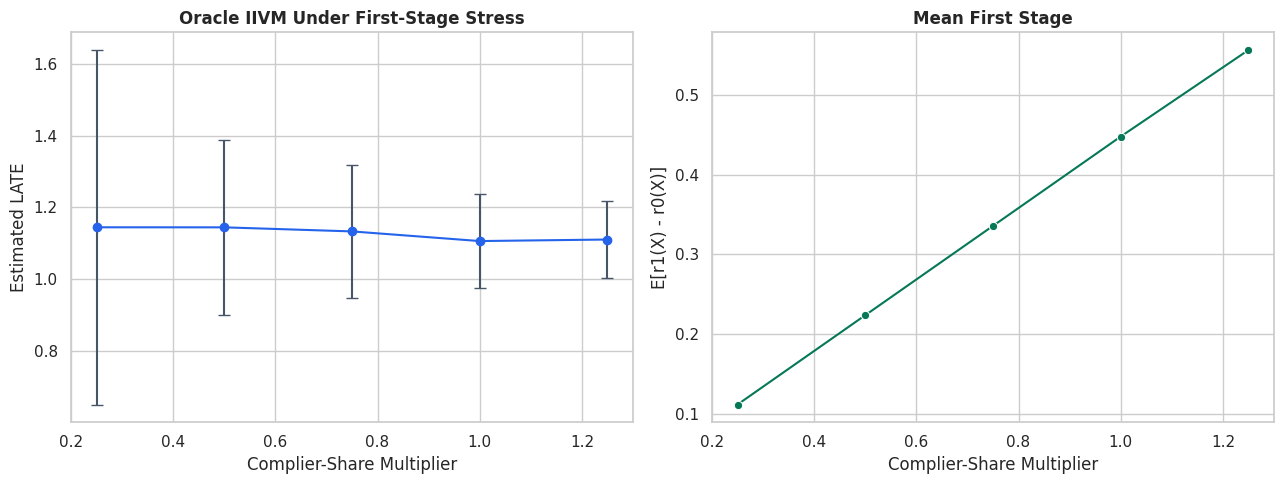

In [32]:
# Build and label the diagnostic visualization for the Weak-Instrument Plot section.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].errorbar(
    x=weak_instrument_table["first_stage_multiplier"],
    y=weak_instrument_table["theta_hat_oracle_iivm"],
    yerr=[
        weak_instrument_table["theta_hat_oracle_iivm"] - weak_instrument_table["ci_95_lower"],
        weak_instrument_table["ci_95_upper"] - weak_instrument_table["theta_hat_oracle_iivm"],
    ],
    fmt="o-",
    color="#2563eb",
    ecolor="#475569",
    capsize=4,
)
axes[0].set_title("Oracle IIVM Under First-Stage Stress")
axes[0].set_xlabel("Complier-Share Multiplier")
axes[0].set_ylabel("Estimated LATE")

sns.lineplot(
    data=weak_instrument_table,
    x="first_stage_multiplier",
    y="mean_first_stage",
    marker="o",
    color="#047857",
    ax=axes[1],
)
axes[1].set_title("Mean First Stage")
axes[1].set_xlabel("Complier-Share Multiplier")
axes[1].set_ylabel("E[r1(X) - r0(X)]")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_weak_instrument_stress_test.png", dpi=160, bbox_inches="tight")
plt.show()


The first stage is the denominator of the estimate. When it gets small, a local-effect estimate can become noisy even if the instrument is valid.



#### Exclusion-Violation Stress Test

Now we break the exclusion restriction by adding a direct effect of the instrument to the outcome.

The calculation uses oracle nuisance functions so the design violation is isolated. If the instrument affects the outcome directly, the IV ratio no longer recovers the treatment effect for compliers.

In [33]:
# Save the artifacts produced by the Exclusion-Violation Stress Test section.
exclusion_rows = []
for direct_effect in [0.00, 0.10, 0.25, 0.50]:
    invalid_y = weekly_value + direct_effect * encouragement
    invalid_g0 = true_g0.to_numpy()
    invalid_g1 = true_g1.to_numpy() + direct_effect
    estimate = iivm_ratio_summary(
        invalid_y,
        d,
        z,
        invalid_g0,
        invalid_g1,
        iivm_df["true_instrument_propensity"].to_numpy(),
        iivm_df["true_r0"].to_numpy(),
        iivm_df["true_r1"].to_numpy(),
        f"direct Z effect={direct_effect:.2f}",
    )
    exclusion_rows.append(
        {
            "direct_instrument_effect": direct_effect,
            "theta_hat_oracle_iivm": estimate["theta_hat"],
            "std_error_oracle_iivm": estimate["std_error"],
            "ci_95_lower": estimate["ci_95_lower"],
            "ci_95_upper": estimate["ci_95_upper"],
            "true_late_without_direct_effect": TRUE_LATE,
            "bias_vs_true_late": estimate["theta_hat"] - TRUE_LATE,
        }
    )

exclusion_violation_table = pd.DataFrame(exclusion_rows)
save_table(exclusion_violation_table, "exclusion_violation_stress_test")
display(exclusion_violation_table)


,direct_instrument_effect,theta_hat_oracle_iivm,std_error_oracle_iivm,ci_95_lower,ci_95_upper,true_late_without_direct_effect,bias_vs_true_late
0,0.00,1.116161,0.064275,0.990182,1.242139,1.101928,0.014233
1,0.10,1.327639,0.064680,1.200866,1.454412,1.101928,0.225711
2,0.25,1.644857,0.066289,1.514931,1.774783,1.101928,0.542929
3,0.50,2.173553,0.071402,2.033606,2.313501,1.101928,1.071626


The estimate moves as the direct instrument effect grows. This is the central IV warning: a strong first stage does not protect against a bad exclusion restriction.



#### Exclusion-Violation Plot

The next figure visualizes how direct instrument effects bias the local-effect estimate.

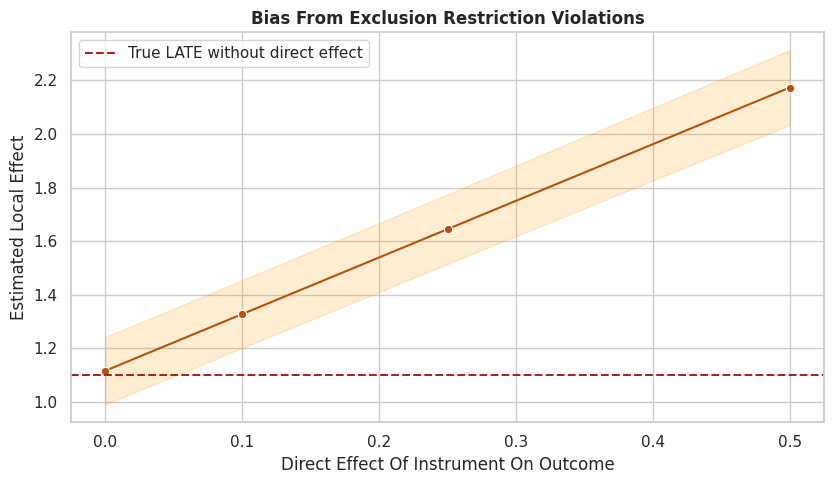

In [34]:
fig, ax = plt.subplots(figsize=(8.5, 5))
sns.lineplot(
    data=exclusion_violation_table,
    x="direct_instrument_effect",
    y="theta_hat_oracle_iivm",
    marker="o",
    color="#b45309",
    ax=ax,
)
ax.fill_between(
    exclusion_violation_table["direct_instrument_effect"],
    exclusion_violation_table["ci_95_lower"],
    exclusion_violation_table["ci_95_upper"],
    color="#f59e0b",
    alpha=0.18,
)
ax.axhline(TRUE_LATE, color="#b91c1c", linestyle="--", linewidth=1.5, label="True LATE without direct effect")
ax.set_title("Bias From Exclusion Restriction Violations")
ax.set_xlabel("Direct Effect Of Instrument On Outcome")
ax.set_ylabel("Estimated Local Effect")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_exclusion_violation_stress_test.png", dpi=160, bbox_inches="tight")
plt.show()


This plot shows why instrument design has to be argued carefully. The model can estimate a ratio, but the ratio is causal only under the IV assumptions.



#### IIVM Compared with IRM

A tempting mistake is to fit a binary-treatment IRM model and treat it as equivalent to IIVM. They target different quantities.

The code below fits a gradient-boosted IRM ATE on the same observed treatment and controls. Because treatment is confounded by compliance-related latent factors, the IRM ATE is not the right design here.

In [35]:
irm_comparison = DoubleMLIRM(
    DoubleMLData(
        iivm_df[["weekly_value", "feature_exposure"] + feature_cols],
        y_col="weekly_value",
        d_cols="feature_exposure",
        x_cols=feature_cols,
    ),
    ml_g=clone(hgb_outcome_learner),
    ml_m=clone(hgb_treatment_learner),
    n_folds=5,
    n_rep=1,
    score="ATE",
)
irm_comparison.fit(store_predictions=True)

irm_vs_iivm = pd.concat(
    [
        irm_comparison.summary.reset_index().rename(columns={"index": "treatment"}).assign(model="IRM ATE on observed treatment", target_reference=TRUE_ATE),
        iivm_hgb.summary.reset_index().rename(columns={"index": "treatment"}).assign(model="IIVM LATE with instrument", target_reference=TRUE_LATE),
    ],
    ignore_index=True,
)
irm_vs_iivm["bias_vs_reference"] = irm_vs_iivm["coef"] - irm_vs_iivm["target_reference"]
save_table(irm_vs_iivm, "irm_vs_iivm_comparison")
display(irm_vs_iivm)


,treatment,coef,std err,t,P>|t|,2.5 %,97.5 %,model,target_reference,bias_vs_reference
0,feature_exposure,1.215977,0.038908,31.252567,2.060239e-214,1.139719,1.292236,IRM ATE on observed treatment,1.020535,0.195442
1,feature_exposure,1.161802,0.083645,13.889707,7.313355e-44,0.997861,1.325743,IIVM LATE with instrument,1.101928,0.059874


The IRM and IIVM estimates answer different questions. In this simulation, the IIVM design is the appropriate response to noncompliance and latent treatment selection.



#### When IIVM is the Right or Wrong Tool

IIVM is useful when:

- treatment is binary;
- instrument is binary;
- noncompliance is central;
- the instrument plausibly shifts treatment but does not directly affect outcome;
- the desired target is a local effect for instrument-responsive units.

IIVM is not enough when:

- the instrument is weak;
- the instrument directly affects the outcome;
- defiers are plausible and monotonicity is not defensible;
- the desired target is the full-population ATE;
- treatment or instrument are continuous rather than binary.




## Reporting and Takeaways

### Reporting Checklist

A useful IIVM report should make the local-effect meaning impossible to miss.

The checklist below captures the design and diagnostics needed for binary IV reporting.

| item | status |
| --- | --- |
| Causal question | Estimate the local effect of feature_exposure on weekly_value for instrument-responsive units. |
| Treatment and instrument | Both feature_exposure and encouragement are binary. |
| Target | LATE, not full-population ATE. |
| Instrument relevance | First-stage take-up diagnostics reported. |
| Instrument overlap | Instrument propensity diagnostics reported. |
| Exclusion | Valid by construction in the synthetic data; requires design evidence in real data. |
| Conditional independence | Valid by construction after X in the synthetic data; requires design evidence in real data. |
| Monotonicity | No defiers by construction; requires design evidence in real data. |
| Nuisance learners | Compared linear/logistic and gradient-boosted nuisance sets. |
| Cross-fitting | Manual ratio and DoubleMLIIVM use cross-fitted nuisance predictions. |
| Uncertainty | Standard errors, confidence intervals, bootstrap interval, and split stability included. |
| Stress tests | Weak first-stage and exclusion-violation stress tests included. |


The checklist separates estimable diagnostics from assumptions. That separation matters even more for IV than for ordinary observed-control designs.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->


### Report Template

The next cell writes a short markdown report template using the main gradient-boosted IIVM estimate.

This template keeps the local-effect target, first stage, instrument assumptions, and limitations close to the numeric estimate.

In [36]:
main_row = iivm_summary.loc[iivm_summary["estimator"] == "Gradient boosting nuisance IIVM"].iloc[0]
first_stage_mean = dml_first_stage_summary.loc[
    dml_first_stage_summary["diagnostic"] == "mean first stage r1_hat - r0_hat", "value"
].iloc[0]

report_text = f"""
# IIVM Local Effect Estimate Report Template

## Causal Question
Estimate the local effect of `feature_exposure` on `weekly_value` for units whose treatment status is shifted by `encouragement`.

## Target
The target is LATE, not the full-population ATE. The estimate applies to the instrument-responsive margin under the IV assumptions.

## Main Estimate
- Estimated local effect: {main_row['theta_hat']:.4f}
- Standard error: {main_row['std_error']:.4f}
- 95 percent confidence interval: [{main_row['ci_95_lower']:.4f}, {main_row['ci_95_upper']:.4f}]

## First Stage
- Mean estimated first stage: {first_stage_mean:.4f}

## Estimator
The main estimator is `DoubleMLIIVM` with five-fold cross-fitting, histogram gradient-boosted outcome nuisance models, and histogram gradient-boosted classifiers for instrument and treatment take-up nuisance models.

## Diagnostics Included
- Direct treatment comparisons, raw Wald, residualized Wald, oracle ratio, manual cross-fitted IIVM, and DoubleML IIVM comparisons.
- Compliance-type summary for the synthetic example data.
- Instrument overlap diagnostics.
- First-stage distribution diagnostics.
- Nuisance learner losses and prediction checks.
- Orthogonal score contribution checks.
- Bootstrap confidence interval.
- Repeated sample-splitting stability.
- Subgroup assumption variants.
- Weak first-stage and exclusion-violation stress tests.

## Required Assumptions
The local effect is causal only if the instrument is relevant, has no direct effect on the outcome, is conditionally independent after controls, satisfies monotonicity, and has adequate overlap. DoubleML estimates the score under these assumptions; it does not establish them.
""".strip()

report_path = REPORT_DIR / f"{NOTEBOOK_PREFIX}_iivm_report_template.md"
report_path.write_text(report_text)
print(report_text)


# IIVM Local Effect Estimate Report Template

## Causal Question
Estimate the local effect of `feature_exposure` on `weekly_value` for units whose treatment status is shifted by `encouragement`.

## Target
The target is LATE, not the full-population ATE. The estimate applies to the instrument-responsive margin under the IV assumptions.

## Main Estimate
- Estimated local effect: 1.1618
- Standard error: 0.0836
- 95 percent confidence interval: [0.9979, 1.3257]

## First Stage
- Mean estimated first stage: 0.5122

## Estimator
The main estimator is `DoubleMLIIVM` with five-fold cross-fitting, histogram gradient-boosted outcome nuisance models, and histogram gradient-boosted classifiers for instrument and treatment take-up nuisance models.

## Diagnostics Included
- Direct treatment comparisons, raw Wald, residualized Wald, oracle ratio, manual cross-fitted IIVM, and DoubleML IIVM comparisons.
- Compliance-type summary for the synthetic example data.
- Instrument overlap diagnostics.
- F

The report template is deliberately explicit about local-effect meaning. That is the most common place where binary IV results get overclaimed.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->


The IIVM notebook is complete. The next natural topic is difference-in-differences, where the identifying assumption shifts from observed-control adjustment or instruments to parallel trends.